In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

import pandas as pd
import seaborn as sns
import os
from statsmodels.stats.multitest import fdrcorrection
# from google.colab import drive
# drive.mount('/content/drive')

from scipy.stats import zscore
from scipy import stats

import statsmodels.api as sm

from pymer4.models import Lmer, Lm

# !pip install scikit-bio

In [2]:
# mixed_batch_data = pd.read_csv('/content/drive/MyDrive/curvefit_traits_merged_linearpf_onlyneccols.csv', index_col='subID')
mixed_batch_data = pd.read_csv('../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
mixed_batch_data.drop('Unnamed: 0', axis=1, inplace=True)
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [3]:
mixed_batch_data.isna().sum()

PSE_subt             0
range_subt           0
bias_subt            0
sigma_subt           0
PSE_pf               0
slope_pf             0
range_pf             0
bias_pf              0
social_skill         0
attn_switch          0
img                  0
attn_to_det          0
comm                 0
posAffect            0
negAffect            0
neuroticism          0
extraversion         0
openness             0
agreeableness        0
conscientiousness    0
loneliness           0
nfriends             1
dtype: int64

Looks like one subject is missing a value for `nfriends`. Let's just drop them as this will cause headaches later

In [4]:
mixed_batch_data = mixed_batch_data.dropna()
mixed_batch_data.shape

(274, 22)

In [5]:
mixed_batch_data.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [6]:
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]
trait_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'posAffect',
              'negAffect',
              'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              'loneliness',
              'nfriends'
       ]

social_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'loneliness',
              'nfriends'
       ]

In [7]:
results_loc= '../../results/subtlety_playfight_mixed/trait-beh/'

In [8]:
# first, super important to z-score all the features in order to minimize the impact of different features being measured on different scales (just like PCA)
mixed_batch_data_zscored = mixed_batch_data.apply(zscore)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,0.144545,-0.206179,0.740744,0.802900,0.052813,1.249255,1.403779,...,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,-0.836964,0.619923,1.390323,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,1.249255,0.813345,...,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,-0.453342,0.095984,0.670868,0.414827,-0.278646,1.011263,1.084710,0.192006,0.604630,2.584649,...,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,0.813243,1.624863,0.816307,-0.399448,1.248505,0.227830,0.268579,-1.585944,-0.845776,-1.154772,...,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-0.413524,-0.604109,-0.212045,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.329245,-0.170714,...,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.876526,-0.335034,-0.276210,-0.256498,0.258657,2.216193,0.419721,...,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.903194,0.770473,1.393153,-1.871185,0.603566,0.726018,0.787560,-1.585402,0.282318,-0.367525,...,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.479799,1.682444,1.192794,-1.161440,-0.847731,0.750763,0.813338,1.392306,0.443474,1.797403,...,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [9]:
mixed_batch_data_zscored.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [10]:
results_loc

'../../results/subtlety_playfight_mixed/trait-beh/'

In [11]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [12]:
cmap = 'BrBG'#'RdBu_r'


In [13]:
abbr = ['soc', 'attn', 'img','det', 'comm', 'pos', 'neg', 'neur', 'extr', 'open', 'agree', 'consc', 'lone', 'num fr.']

In [14]:
start_ind = list(mixed_batch_data_zscored.columns).index('social_skill')
start_ind

8

In [15]:
mixed_batch_data_zscored.iloc[:,start_ind:].shape

(274, 14)

In [16]:
mixed_batch_data_zscored.iloc[:,start_ind:]

,social_skill,attn_switch,img,attn_to_det,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,
30002.0,1.249255,1.403779,-0.345055,-1.202936,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,1.249255,0.813345,-0.345055,-0.143644,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,0.604630,2.584649,2.396116,0.068214,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,-0.845776,-1.154772,-1.258778,-1.202936,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-1.329245,-0.170714,0.340238,0.280072,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,2.216193,0.419721,1.939254,0.915647,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.282318,-0.367525,-1.030347,-0.567361,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.443474,1.797403,-0.801916,0.068214,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


<Axes: >

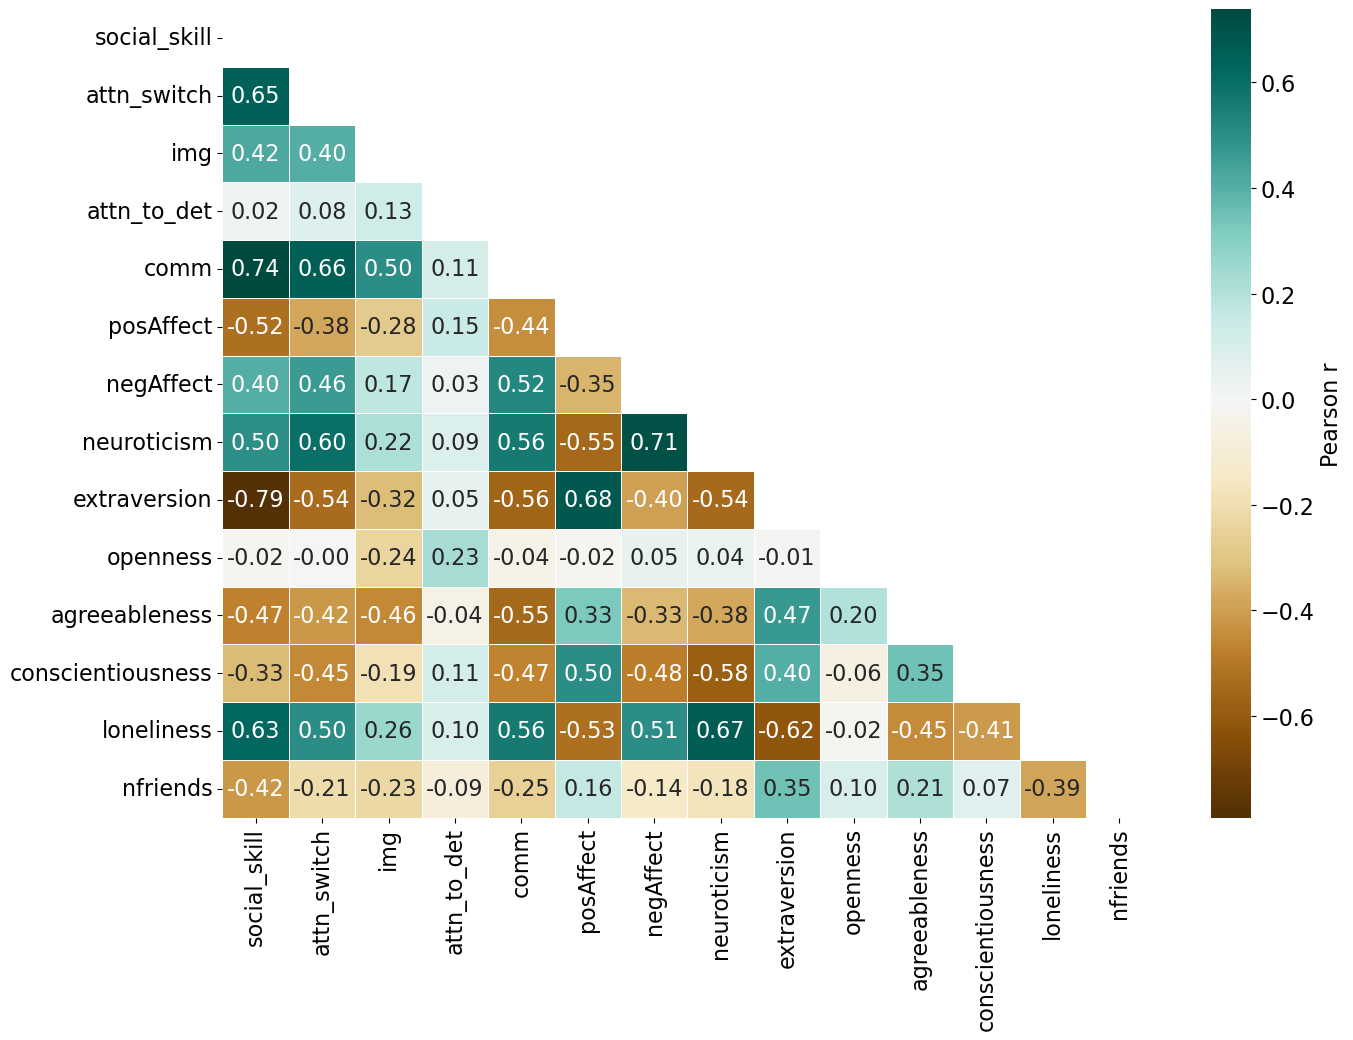

In [17]:
correlation_matrix = mixed_batch_data_zscored.iloc[:,start_ind:].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
fig,ax = plt.subplots(figsize=(15, 10.5))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,  center=0,ax=ax,  annot_kws={"size": 16}, linecolor='w', linewidths=0.5, cbar=True, cbar_kws={'label': 'Pearson r'})
# ax.set_xticklabels(abbr, rotation=45, ha='right')
# ax.set_yticklabels(abbr, rotation=0, ha='right')
# plt.savefig(results_loc + 'correlation_matrix.png', dpi=300)

In [18]:
correlation_matrix

,social_skill,attn_switch,img,attn_to_det,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
social_skill,1.000000,0.651457,0.422224,0.022485,0.739122,-0.524639,0.401585,0.499463,-0.792255,-0.017040,-0.472108,-0.331438,0.628299,-0.416067
attn_switch,0.651457,1.000000,0.399697,0.077259,0.655895,-0.376240,0.463660,0.600411,-0.536269,-0.001716,-0.416122,-0.453935,0.502605,-0.211569
img,0.422224,0.399697,1.000000,0.130238,0.501056,-0.280176,0.174172,0.218384,-0.320467,-0.238261,-0.457135,-0.191682,0.260362,-0.225072
attn_to_det,0.022485,0.077259,0.130238,1.000000,0.112433,0.152403,0.029610,0.092395,0.052902,0.231988,-0.044557,0.108522,0.103428,-0.085958
comm,0.739122,0.655895,0.501056,0.112433,1.000000,-0.440665,0.520765,0.564758,-0.559452,-0.038992,-0.549475,-0.468265,0.562081,-0.254844
posAffect,-0.524639,-0.376240,-0.280176,0.152403,-0.440665,1.000000,-0.349001,-0.550069,0.684988,-0.016450,0.325181,0.504911,-0.527283,0.162000
negAffect,0.401585,0.463660,0.174172,0.029610,0.520765,-0.349001,1.000000,0.705351,-0.398656,0.045812,-0.332468,-0.483974,0.505272,-0.135602
neuroticism,0.499463,0.600411,0.218384,0.092395,0.564758,-0.550069,0.705351,1.000000,-0.542251,0.042471,-0.375244,-0.582064,0.666153,-0.175210
extraversion,-0.792255,-0.536269,-0.320467,0.052902,-0.559452,0.684988,-0.398656,-0.542251,1.000000,-0.012986,0.466721,0.404034,-0.617644,0.348207
openness,-0.017040,-0.001716,-0.238261,0.231988,-0.038992,-0.016450,0.045812,0.042471,-0.012986,1.000000,0.204206,-0.061176,-0.017974,0.102002


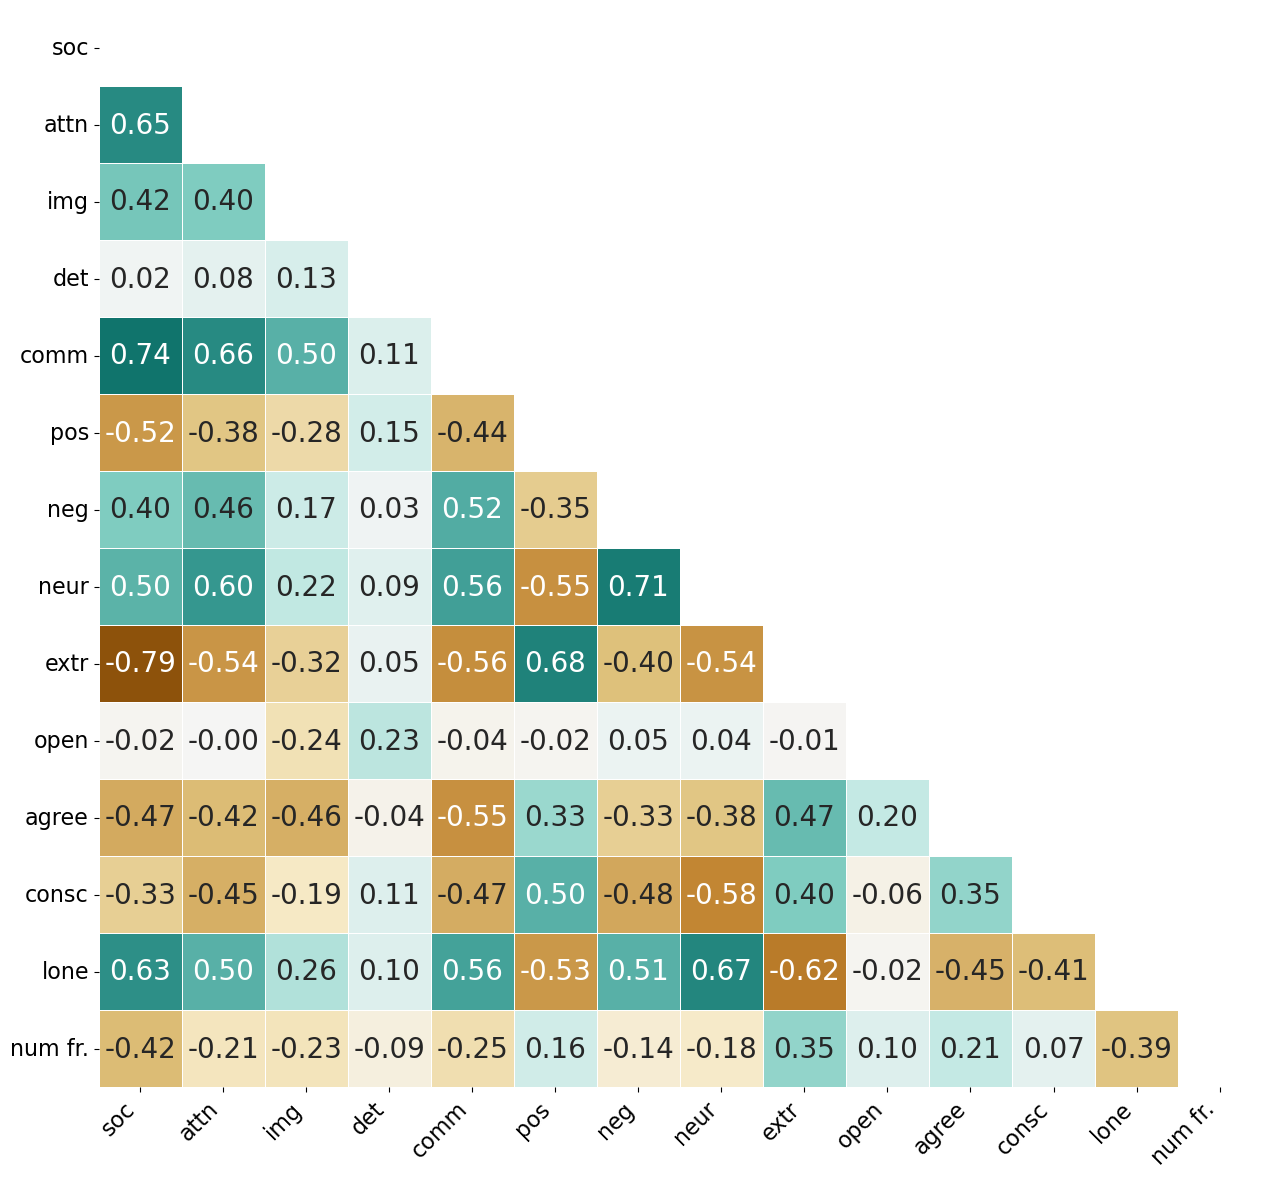

In [19]:
correlation_matrix = mixed_batch_data_zscored.iloc[:,start_ind:].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
fig,ax = plt.subplots(figsize=(15, 14))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, center=0,ax=ax,  annot_kws={"size": 20}, linecolor='w', linewidths=0.5, cbar=False)#, cbar_kws={'label': 'Pearson r'})
ax.set_xticklabels(abbr, rotation=45, ha='right')
ax.set_yticklabels(abbr, rotation=0, ha='right')
plt.savefig(results_loc + 'correlation_matrix.png', dpi=300, bbox_inches='tight')

In [20]:
from statsmodels.stats.multitest import fdrcorrection

def generate_samples(dataset, n):
    return list(np.random.choice(dataset, size=n, replace=True))

# looking at the difference index with z-scored data

In [21]:
bias_PSE_subt_diff = mixed_batch_data_zscored['bias_subt'] - mixed_batch_data_zscored['PSE_subt']
bias_PSE_pf_diff = mixed_batch_data_zscored['bias_pf'] - mixed_batch_data_zscored['PSE_pf']

mixed_batch_data_zscored.insert(3, 'bias_PSE_subt_diff', bias_PSE_subt_diff)
mixed_batch_data_zscored.insert(9, 'bias_PSE_pf_diff', bias_PSE_pf_diff)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,bias_PSE_subt_diff,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,bias_PSE_pf_diff,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,-3.769566,0.144545,-0.206179,0.740744,0.802900,0.052813,0.258992,...,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,-0.836964,0.619923,1.390323,2.227287,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,-3.059932,...,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,-0.453342,0.095984,0.670868,1.124210,0.414827,-0.278646,1.011263,1.084710,0.192006,0.470651,...,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,0.813243,1.624863,0.816307,0.003064,-0.399448,1.248505,0.227830,0.268579,-1.585944,-2.834449,...,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-0.413524,-0.604109,-0.212045,0.201478,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.291524,...,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.415964,0.876526,-0.335034,-0.276210,-0.256498,0.258657,0.593691,...,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.903194,0.770473,1.393153,0.489960,-1.871185,0.603566,0.726018,0.787560,-1.585402,-2.188969,...,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.479799,1.682444,1.192794,0.712995,-1.161440,-0.847731,0.750763,0.813338,1.392306,2.240037,...,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [22]:
param = 'bias_PSE_subt_diff'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
print(model.fit())#

Formula: bias_PSE_subt_diff~social_skill+attn_switch+img+attn_to_det+comm+posAffect+negAffect+neuroticism+extraversion+openness+agreeableness+conscientiousness+loneliness+nfriends

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.091	 R^2_adj: 0.041

Log-likelihood: -520.759 	 AIC: 1071.518	 BIC: 1125.715

Fixed effects:

                   Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept             0.000  -0.198    0.198  0.101  259   0.000  1.000    
social_skill          0.094  -0.352    0.540  0.226  259   0.414  0.679    
attn_switch           0.258  -0.049    0.564  0.156  259   1.657  0.099   .
img                   0.138  -0.117    0.394  0.130  259   1.067  0.287    
attn_to_det           0.036  -0.190    0.262  0.115  259   0.314  0.754    
comm                 -0.532  -0.900   -0.165  0.187  259  -2.854  0.005  **
posAffect            -0.001  -0.314    0.312  0.159  259  

In [23]:
param = 'bias_PSE_pf_diff'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
print(model.fit())#

Formula: bias_PSE_pf_diff~social_skill+attn_switch+img+attn_to_det+comm+posAffect+negAffect+neuroticism+extraversion+openness+agreeableness+conscientiousness+loneliness+nfriends

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.049	 R^2_adj: -0.002

Log-likelihood: -549.454 	 AIC: 1128.907	 BIC: 1183.104

Fixed effects:

                   Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept             0.000  -0.220    0.220  0.112  259   0.000  1.000    
social_skill         -0.019  -0.515    0.476  0.251  259  -0.077  0.939    
attn_switch           0.020  -0.320    0.361  0.173  259   0.117  0.907    
img                  -0.022  -0.306    0.261  0.144  259  -0.155  0.877    
attn_to_det           0.134  -0.117    0.385  0.128  259   1.049  0.295    
comm                 -0.114  -0.522    0.294  0.207  259  -0.550  0.583    
posAffect            -0.086  -0.433    0.262  0.176  259  -

In [24]:
param = 'range_subt'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
print(model.fit())#

Formula: range_subt~social_skill+attn_switch+img+attn_to_det+comm+posAffect+negAffect+neuroticism+extraversion+openness+agreeableness+conscientiousness+loneliness+nfriends

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.047	 R^2_adj: -0.005

Log-likelihood: -382.250 	 AIC: 794.499	 BIC: 848.696

Fixed effects:

                   Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept            -0.000  -0.119    0.119  0.061  259  -0.000  1.000    
social_skill          0.150  -0.119    0.419  0.137  259   1.097  0.274    
attn_switch           0.041  -0.144    0.226  0.094  259   0.436  0.663    
img                  -0.022  -0.176    0.132  0.078  259  -0.287  0.774    
attn_to_det          -0.020  -0.156    0.116  0.069  259  -0.289  0.773    
comm                 -0.168  -0.390    0.054  0.113  259  -1.493  0.137    
posAffect            -0.125  -0.314    0.064  0.096  259  -1.306  0

In [26]:
param = 'range_pf'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
print(model.fit())#

Formula: range_pf~social_skill+attn_switch+img+attn_to_det+comm+posAffect+negAffect+neuroticism+extraversion+openness+agreeableness+conscientiousness+loneliness+nfriends

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.112	 R^2_adj: 0.064

Log-likelihood: -372.516 	 AIC: 775.032	 BIC: 829.229

Fixed effects:

                   Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept            -0.000  -0.115    0.115  0.059  259  -0.000  1.000    
social_skill          0.121  -0.139    0.380  0.132  259   0.917  0.360    
attn_switch           0.168  -0.010    0.347  0.091  259   1.856  0.065   .
img                  -0.006  -0.154    0.143  0.075  259  -0.076  0.940    
attn_to_det          -0.041  -0.173    0.091  0.067  259  -0.613  0.541    
comm                 -0.227  -0.440   -0.013  0.109  259  -2.086  0.038   *
posAffect             0.092  -0.091    0.274  0.092  259   0.990  0.32

In [26]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

# bootstrapping

In [27]:
import matplotlib.patches as patches

In [28]:
# bootstrap both
# takes time. run this ONLY if we eed to run another bootstrap. no need to re-run to redo just the plots

# nbootstraps = 1000

# param = 'bias_PSE_subt_diff'
# model1_og_psez_biasz = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model1_og_psez_biasz.fit(summary=False)
# true_estimate_subtlety_psez_biasz = model1_og_psez_biasz.coefs['Estimate'].values

# param = 'bias_PSE_pf_diff'
# model2_og_psez_biasz = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model2_og_psez_biasz.fit(summary=False)
# true_estimate_pf_psez_biasz = model2_og_psez_biasz.coefs['Estimate'].values

# param = 'range_subt'
# model1_og_range = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model1_og_range.fit(summary=False)
# true_estimate_subtlety_range = model1_og_range.coefs['Estimate'].values

# param = 'range_pf'
# model2_og_range = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model2_og_range.fit(summary=False)
# true_estimate_pf_range = model2_og_range.coefs['Estimate'].values

# estimates_subt_biasz_PSEz = np.full((nbootstraps,15),np.nan)
# estimates_pf_biasz_PSEz = np.full((nbootstraps,15),np.nan)
# estimates_subt_range = np.full((nbootstraps,15),np.nan)
# estimates_pf_range = np.full((nbootstraps,15),np.nan)
# for i in range(nbootstraps):
#     inds = generate_samples(np.arange(0,mixed_batch_data_zscored.shape[0]), mixed_batch_data_zscored.shape[0])
#     df_bootstrap = mixed_batch_data_zscored.iloc[inds,:]
    
#     param = 'bias_PSE_subt_diff' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_subt_biasz_PSEz[i,:] = model.coefs.Estimate.values

#     param = 'range_subt' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_subt_range[i,:] = model.coefs.Estimate.values

#     param = 'bias_PSE_pf_diff' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_pf_biasz_PSEz[i,:] = model.coefs.Estimate.values

#     param = 'range_pf' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_pf_range[i,:] = model.coefs.Estimate.values

#     if i == 0:
#         colnames = model.coefs.index

# df_bootstrap_results_subt_biasz_PSEz = pd.DataFrame(data=estimates_subt_biasz_PSEz,columns=colnames)
# df_bootstrap_results_subt_biasz_PSEz = df_bootstrap_results_subt_biasz_PSEz.iloc[:,1:] # remove intercept

# df_bootstrap_results_pf_biasz_PSEz = pd.DataFrame(data=estimates_pf_biasz_PSEz,columns=colnames)
# df_bootstrap_results_pf_biasz_PSEz = df_bootstrap_results_pf_biasz_PSEz.iloc[:,1:] # remove intercept

# df_bootstrap_results_subt_range = pd.DataFrame(data=estimates_subt_range,columns=colnames)
# df_bootstrap_results_subt_range = df_bootstrap_results_subt_range.iloc[:,1:] # remove intercept

# df_bootstrap_results_pf_range = pd.DataFrame(data=estimates_pf_range,columns=colnames)
# df_bootstrap_results_pf_range = df_bootstrap_results_pf_range.iloc[:,1:] # remove intercept


# df_bootstrap_results_subt_biasz_PSEz.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_PSEz_biasz.csv')
# df_bootstrap_results_pf_biasz_PSEz.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_PSEz_biasz.csv')

# df_bootstrap_results_subt_range.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_range.csv')
# df_bootstrap_results_pf_range.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_range.csv')

In [29]:
# nbootstraps = 1000

# param = 'bias_PSE_subt_diff'
# model1_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model1_og.fit(summary=False)
# true_estimate_subtlety = model1_og.coefs['Estimate'].values

# param = 'bias_PSE_pf_diff'
# model2_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model2_og.fit(summary=False)
# true_estimate_pf = model2_og.coefs['Estimate'].values

# estimates_subt = np.full((nbootstraps,15),np.nan)
# estimates_pf = np.full((nbootstraps,15),np.nan)
# for i in range(nbootstraps):
#     inds = generate_samples(np.arange(0,mixed_batch_data_zscored.shape[0]), mixed_batch_data_zscored.shape[0])
#     df_bootstrap = mixed_batch_data_zscored.iloc[inds,:]
    
#     param = 'bias_PSE_subt_diff' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_subt[i,:] = model.coefs.Estimate.values

#     if i == 0:
#         colnames = model.coefs.index

#     param = 'bias_PSE_pf_diff' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_pf[i,:] = model.coefs.Estimate.values

# df_bootstrap_results_subt = pd.DataFrame(data=estimates_subt,columns=colnames)
# df_bootstrap_results_subt = df_bootstrap_results_subt.iloc[:,1:] # remove intercept

# df_bootstrap_results_pf = pd.DataFrame(data=estimates_pf,columns=colnames)
# df_bootstrap_results_pf = df_bootstrap_results_pf.iloc[:,1:] # remove intercept

# df_bootstrap_results_subt.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt.csv')
# df_bootstrap_results_pf.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf.csv')

In [30]:
df_bootstrap_results_subt_biasz_PSEz = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_PSEz_biasz.csv', index_col=0)
df_bootstrap_results_pf_biasz_PSEz = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_PSEz_biasz.csv', index_col=0)
df_bootstrap_results_subt_range = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_range.csv', index_col=0)
df_bootstrap_results_pf_range = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_range.csv', index_col=0)

In [31]:
# abbr = ['soc', 'attn', 'img','det', 'comm', 'pos', 'neg', 'N', 'E', 'O', 'A', 'C', 'lone', '# fr.']
abbr = ['soc', 'attn', 'img','det', 'comm', 'pos', 'neg', 'neur', 'extr', 'open', 'agree', 'consc', 'lone', 'num fr.']

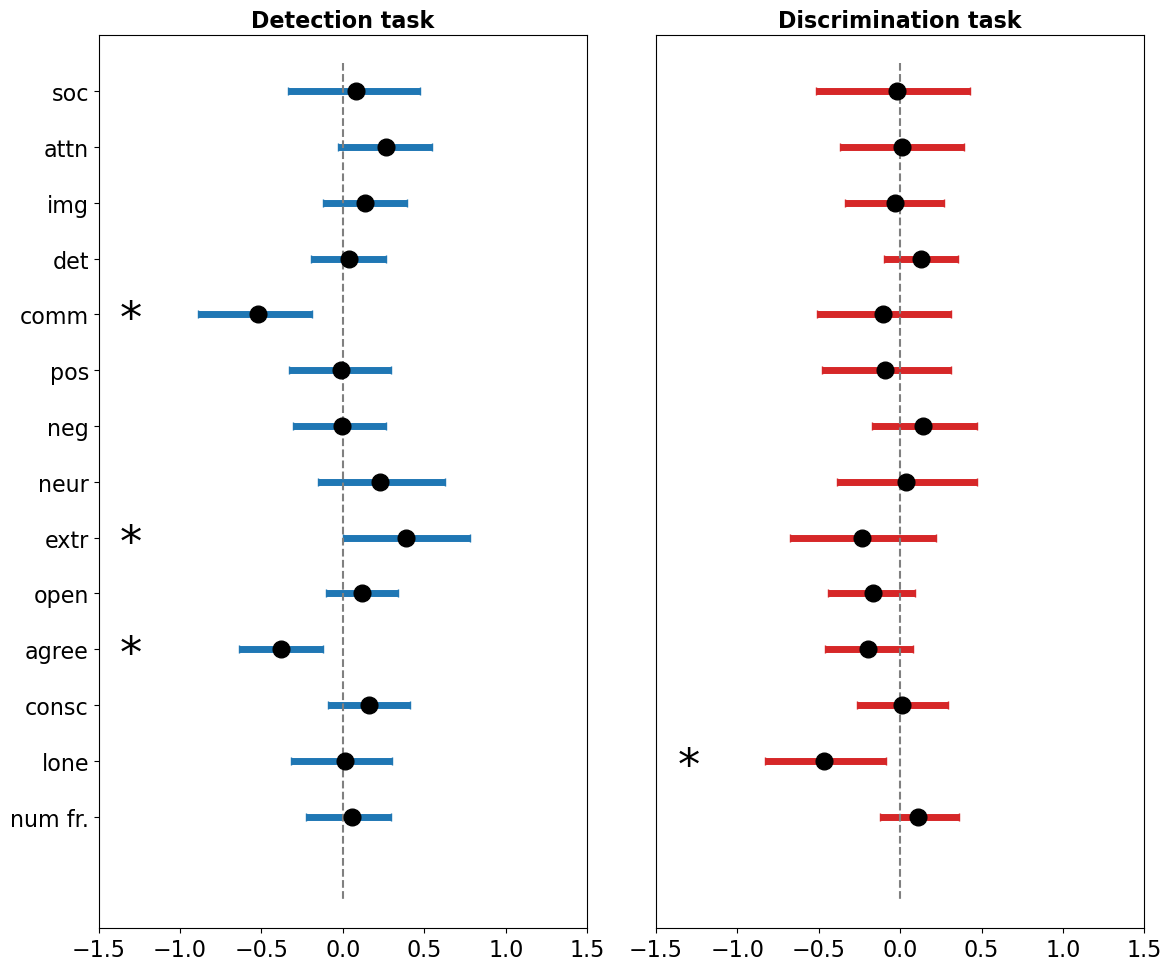

In [58]:

fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,10))

ax = axs[0]
df_subt_quantiles = df_bootstrap_results_subt_biasz_PSEz.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt_biasz_PSEz.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt_biasz_PSEz.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt_biasz_PSEz.max()
# for i, (_,row) in enumerate(df_subt_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='tab:blue',
#         facecolor='white'
#     )
#     ax.add_patch(rect)
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='k', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker
y_pos = range(len(df_subt_quantiles))
ax.errorbar(
    df_subt_quantiles['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles['mean'] - df_subt_quantiles['lower_ci'],
        df_subt_quantiles['upper_ci'] - df_subt_quantiles['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    capsize=3,
    linewidth =5,
    markersize=12
)

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_subt_biasz_PSEz.columns, rotation=0)
ax.set_yticks(range(0,14),abbr, rotation=0)

ax.set_title('Detection task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)

xtext = -1.3
ind = -1
for i,row in df_subt_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

ax = axs[1]
df_pf_quantiles = df_bootstrap_results_pf_biasz_PSEz.quantile([0.025, 0.975])
df_pf_quantiles.index = ['lower_ci', 'upper_ci']
df_pf_quantiles = df_pf_quantiles.transpose()
df_pf_quantiles['mean'] = df_bootstrap_results_pf_biasz_PSEz.mean()
df_pf_quantiles['min'] = df_bootstrap_results_pf_biasz_PSEz.min()
df_pf_quantiles['max'] = df_bootstrap_results_pf_biasz_PSEz.max()

# for i, (_,row) in enumerate(df_pf_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='tab:red',
#         facecolor='white'
#     )
#     ax.add_patch(rect)
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='k', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

y_pos = range(len(df_pf_quantiles))
ax.errorbar(
    df_pf_quantiles['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles['mean'] - df_pf_quantiles['lower_ci'],
        df_pf_quantiles['upper_ci'] - df_pf_quantiles['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    capsize=3,
    linewidth =5,
    markersize=12
)

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(0,14),df_bootstrap_results_pf_biasz_PSEz.columns, rotation=0)
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)
xtext = -1.3
ind = -1
for i,row in df_pf_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_biasz-PSEz_nohighlights.png', dpi=300, bbox_inches = 'tight')

In [35]:
np.sign(df_subt_quantiles['lower_ci'])== np.sign(df_subt_quantiles['upper_ci'])

social_skill         False
attn_switch          False
img                  False
attn_to_det          False
comm                  True
posAffect            False
negAffect            False
neuroticism          False
extraversion          True
openness             False
agreeableness         True
conscientiousness    False
loneliness           False
nfriends             False
dtype: bool

In [ ]:
df_subt_quantiles = df_bootstrap_results_subt_biasz_PSEz.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt_biasz_PSEz.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt_biasz_PSEz.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt_biasz_PSEz.max()
df_subt_quantiles

,lower_ci,upper_ci,mean,min,max,sig
social_skill,-0.335090,0.473478,0.081827,-0.538023,0.700582,False
attn_switch,-0.032425,0.550004,0.264220,-0.233598,0.846325,False
img,-0.122088,0.396528,0.135350,-0.273681,0.560160,False
attn_to_det,-0.193769,0.266414,0.037323,-0.333461,0.443816,False
comm,-0.886842,-0.189134,-0.523846,-1.062561,0.258094,True
posAffect,-0.332153,0.292447,-0.013385,-0.536589,0.435203,False
negAffect,-0.303806,0.262488,-0.007097,-0.492272,0.394501,False
neuroticism,-0.151091,0.628783,0.226245,-0.307617,0.831311,False
extraversion,0.001676,0.782906,0.386792,-0.257120,1.164024,True
openness,-0.103637,0.339462,0.116596,-0.258875,0.428123,False


In [41]:
df_subt_quantiles_sig.shape

(3, 6)

In [43]:
y_pos.shape

(18,)

In [45]:
df_subt_quantiles.loc[df_subt_quantiles['sig']]

,lower_ci,upper_ci,mean,min,max,sig
comm,-0.886842,-0.189134,-0.523846,-1.062561,0.258094,True
extraversion,0.001676,0.782906,0.386792,-0.257120,1.164024,True
agreeableness,-0.640550,-0.123922,-0.381111,-0.830162,0.083599,True


/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


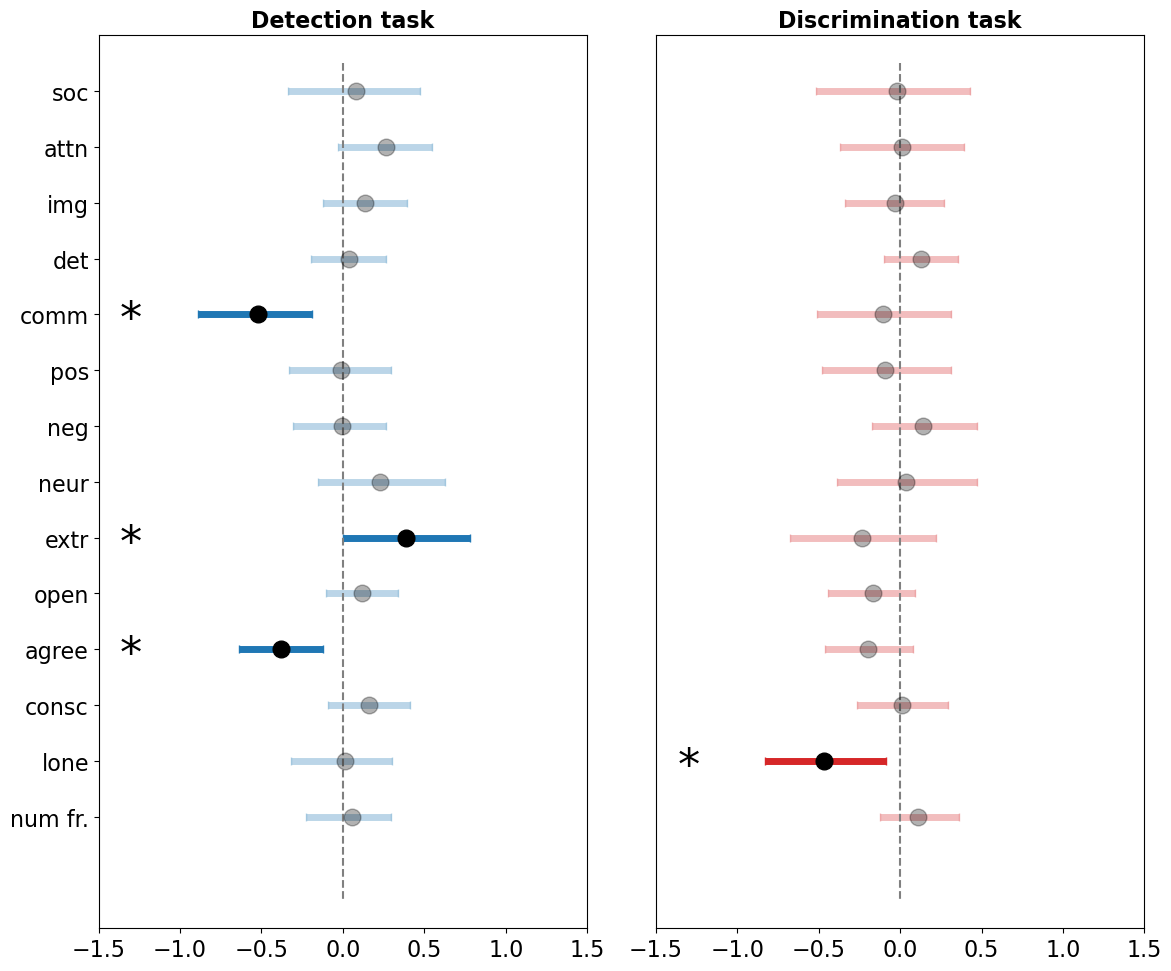

In [57]:
# sig results highlighted

fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,10))

ax = axs[0]
df_subt_quantiles = df_bootstrap_results_subt_biasz_PSEz.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt_biasz_PSEz.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt_biasz_PSEz.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt_biasz_PSEz.max()
df_subt_quantiles['sig'] = np.sign(df_subt_quantiles['lower_ci'])== np.sign(df_subt_quantiles['upper_ci'])

df_subt_quantiles_sig = df_subt_quantiles.loc[df_subt_quantiles['sig']]
y_pos = np.where(df_subt_quantiles['sig'])[0]#range(len(df_subt_quantiles_sig))
ax.errorbar(
    df_subt_quantiles_sig['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles_sig['mean'] - df_subt_quantiles_sig['lower_ci'],
        df_subt_quantiles_sig['upper_ci'] - df_subt_quantiles_sig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    capsize=3,
    linewidth =5,
    markersize=12
)

df_subt_quantiles_nonsig = df_subt_quantiles.loc[~df_subt_quantiles['sig']]
y_pos = np.where(~df_subt_quantiles['sig'])[0]#
# y_pos = range(len(df_subt_quantiles_nonsig))
ax.errorbar(
    df_subt_quantiles_nonsig['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles_nonsig['mean'] - df_subt_quantiles_nonsig['lower_ci'],
        df_subt_quantiles_nonsig['upper_ci'] - df_subt_quantiles_nonsig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    alpha=.3,
    capsize=3,
    linewidth =5,
    markersize=12
)

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_subt_biasz_PSEz.columns, rotation=0)
ax.set_yticks(range(0,14),abbr, rotation=0)

ax.set_title('Detection task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)

xtext = -1.3
ind = -1
for i,row in df_subt_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

ax = axs[1]
df_pf_quantiles = df_bootstrap_results_pf_biasz_PSEz.quantile([0.025, 0.975])
df_pf_quantiles.index = ['lower_ci', 'upper_ci']
df_pf_quantiles = df_pf_quantiles.transpose()
df_pf_quantiles['mean'] = df_bootstrap_results_pf_biasz_PSEz.mean()
df_pf_quantiles['min'] = df_bootstrap_results_pf_biasz_PSEz.min()
df_pf_quantiles['max'] = df_bootstrap_results_pf_biasz_PSEz.max()
df_pf_quantiles['sig'] = np.sign(df_pf_quantiles['lower_ci'])== np.sign(df_pf_quantiles['upper_ci'])

df_pf_quantiles_sig = df_pf_quantiles.loc[df_pf_quantiles['sig']]
y_pos = np.where(df_pf_quantiles['sig'])[0]#range(len(df_subt_quantiles_sig))
ax.errorbar(
    df_pf_quantiles_sig['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles_sig['mean'] - df_pf_quantiles_sig['lower_ci'],
        df_pf_quantiles_sig['upper_ci'] - df_pf_quantiles_sig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    capsize=3,
    linewidth =5,
    markersize=12
)

df_pf_quantiles_nonsig = df_pf_quantiles.loc[~df_pf_quantiles['sig']]
y_pos = np.where(~df_pf_quantiles['sig'])[0]#
ax.errorbar(
    df_pf_quantiles_nonsig['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles_nonsig['mean'] - df_pf_quantiles_nonsig['lower_ci'],
        df_pf_quantiles_nonsig['upper_ci'] - df_pf_quantiles_nonsig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    alpha=.3,
    capsize=3,
    linewidth =5,
    markersize=12
)

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(0,14),df_bootstrap_results_pf_biasz_PSEz.columns, rotation=0)
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)
xtext = -1.3
ind = -1
for i,row in df_pf_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_biasz-PSEz.png', dpi=300, bbox_inches = 'tight')
# plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_biasz-PSEz_sig_results_highlighted.png', dpi=300, bbox_inches = 'tight')

In [37]:
df_subt_quantiles.to_csv('../../results/subtlety_playfight_mixed/trait-beh/trait_beh_multreg_subt_biasz-PSEz.csv')
df_subt_quantiles

,lower_ci,upper_ci,mean,min,max
social_skill,-0.335090,0.473478,0.081827,-0.538023,0.700582
attn_switch,-0.032425,0.550004,0.264220,-0.233598,0.846325
img,-0.122088,0.396528,0.135350,-0.273681,0.560160
attn_to_det,-0.193769,0.266414,0.037323,-0.333461,0.443816
comm,-0.886842,-0.189134,-0.523846,-1.062561,0.258094
posAffect,-0.332153,0.292447,-0.013385,-0.536589,0.435203
negAffect,-0.303806,0.262488,-0.007097,-0.492272,0.394501
neuroticism,-0.151091,0.628783,0.226245,-0.307617,0.831311
extraversion,0.001676,0.782906,0.386792,-0.257120,1.164024
openness,-0.103637,0.339462,0.116596,-0.258875,0.428123


In [38]:
df_pf_quantiles.to_csv('../../results/subtlety_playfight_mixed/trait-beh/trait_beh_multreg_pf_biasz-PSEz.csv')
df_pf_quantiles

,lower_ci,upper_ci,mean,min,max
social_skill,-0.515545,0.426784,-0.019943,-0.936039,0.783971
attn_switch,-0.368337,0.394990,0.014590,-0.668859,0.654261
img,-0.335567,0.267195,-0.028222,-0.510002,0.366909
attn_to_det,-0.099152,0.353879,0.126963,-0.280651,0.470889
comm,-0.507889,0.312504,-0.103872,-0.993657,0.549291
posAffect,-0.479244,0.312243,-0.089690,-0.914250,0.580339
negAffect,-0.171613,0.469712,0.140340,-0.349218,0.703601
neuroticism,-0.384741,0.469394,0.039137,-0.561668,0.674952
extraversion,-0.677146,0.221746,-0.230818,-1.043979,0.494149
openness,-0.441493,0.094190,-0.166236,-0.562963,0.223511


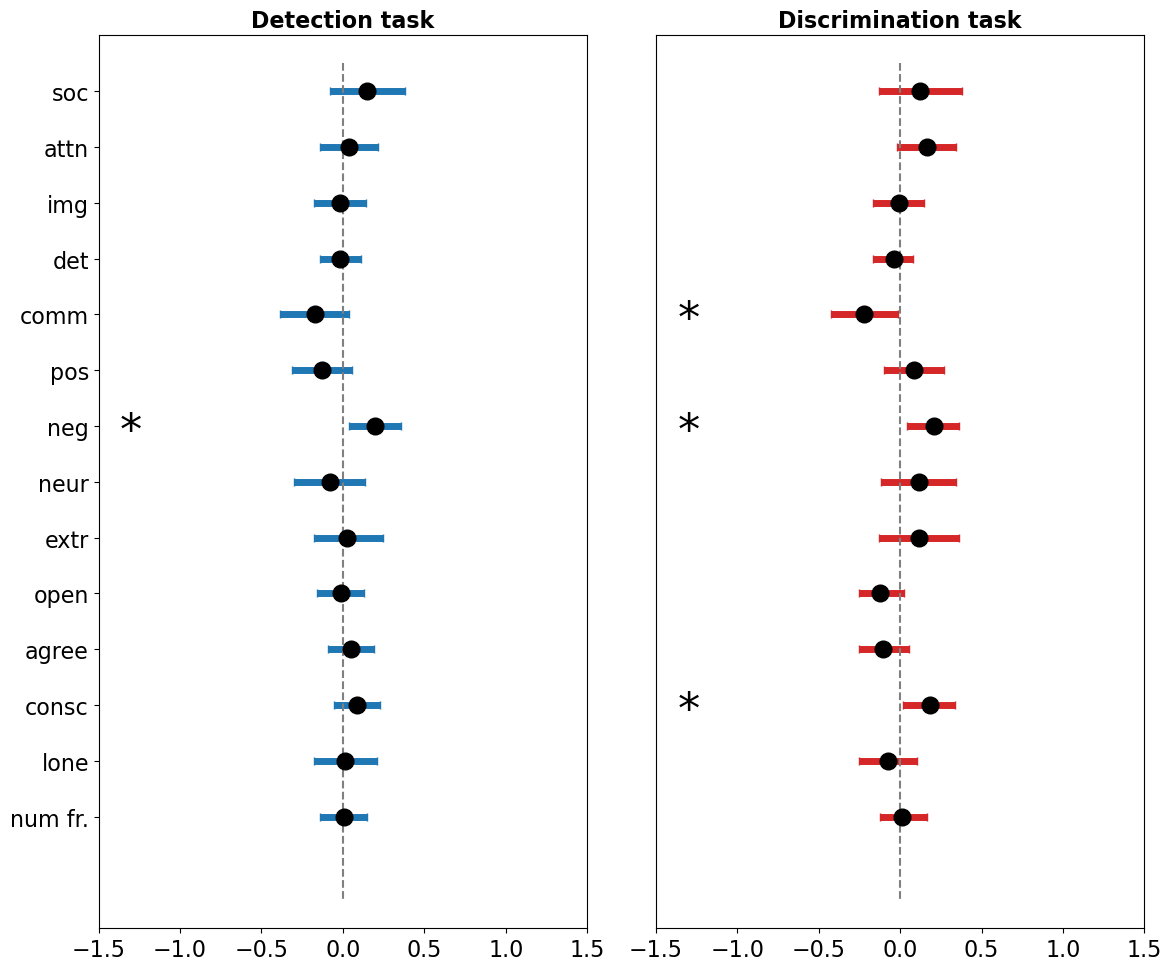

In [59]:
# v4
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,10))

ax = axs[0]
df_subt_quantiles = df_bootstrap_results_subt_range.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt_range.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt_range.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt_range.max()
# for i, (_,row) in enumerate(df_subt_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='tab:blue',
#         facecolor='white'
#     )
#     ax.add_patch(rect)
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='k', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker
y_pos = range(len(df_subt_quantiles))
ax.errorbar(
    df_subt_quantiles['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles['mean'] - df_subt_quantiles['lower_ci'],
        df_subt_quantiles['upper_ci'] - df_subt_quantiles['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    capsize=3,
    linewidth = 5,
    markersize=12
)


ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_subt_range.columns, rotation=0)
ax.set_yticks(range(0,14), abbr, rotation=0)

ax.set_title('Detection task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)

xtext = -1.3
ind = -1
for i,row in df_subt_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind + 0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

ax = axs[1]
df_pf_quantiles = df_bootstrap_results_pf_range.quantile([0.025, 0.975])
df_pf_quantiles.index = ['lower_ci', 'upper_ci']
df_pf_quantiles = df_pf_quantiles.transpose()
df_pf_quantiles['mean'] = df_bootstrap_results_pf_range.mean()
df_pf_quantiles['min'] = df_bootstrap_results_pf_range.min()
df_pf_quantiles['max'] = df_bootstrap_results_pf_range.max()

# for i, (_,row) in enumerate(df_pf_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='tab:red',
#         facecolor='white'
#     )
#     ax.add_patch(rect)
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='k', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

y_pos = range(len(df_pf_quantiles))
ax.errorbar(
    df_pf_quantiles['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles['mean'] - df_pf_quantiles['lower_ci'],
        df_pf_quantiles['upper_ci'] - df_pf_quantiles['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    capsize=3,
    linewidth = 5,
    markersize=12
)

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(0,14),df_bootstrap_results_pf_biasz_PSEz.columns, rotation=0)
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)
xtext = -1.3
ind = -1
for i,row in df_pf_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_range_nohighlights.png', dpi=300, bbox_inches = 'tight')

/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


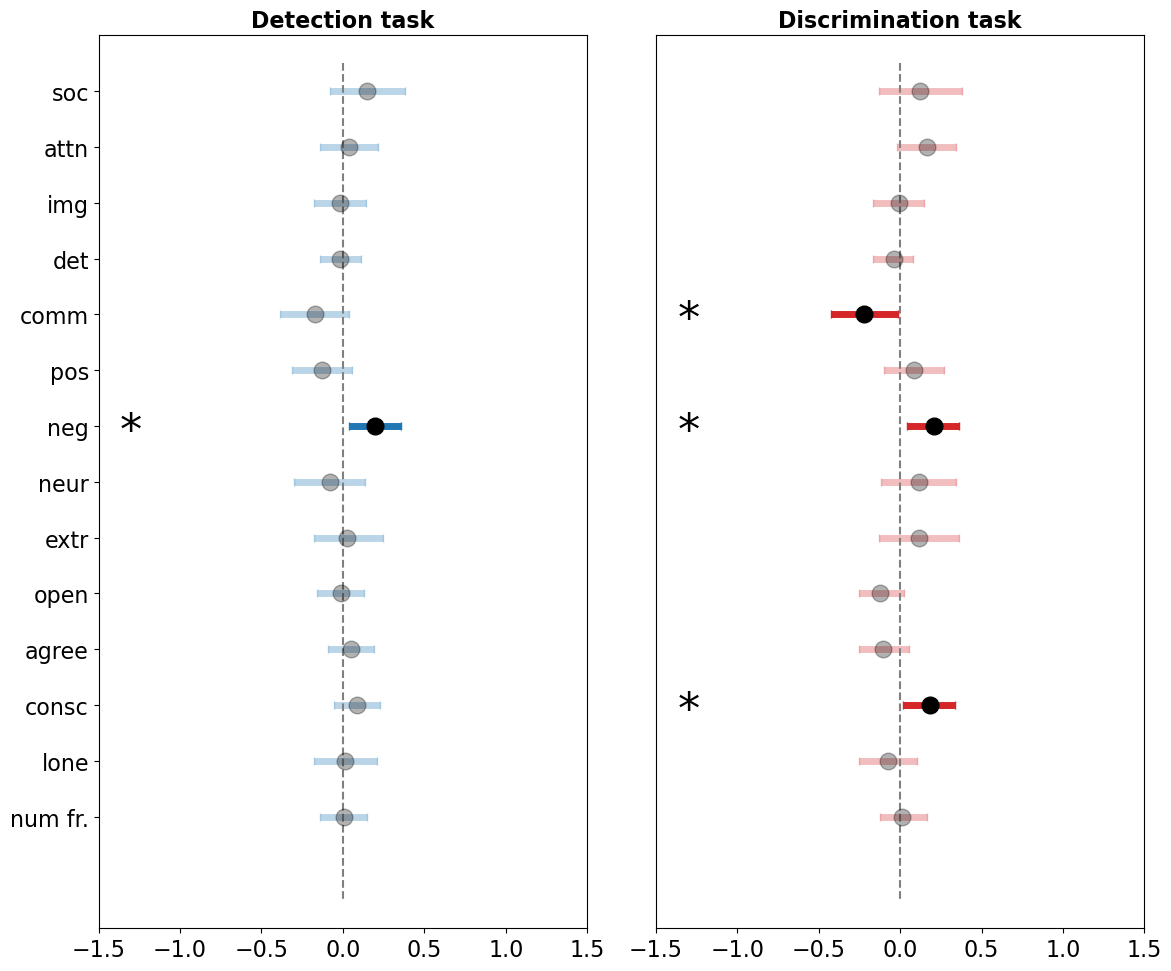

In [56]:
# sig results highlighted
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,10))

ax = axs[0]
df_subt_quantiles = df_bootstrap_results_subt_range.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt_range.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt_range.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt_range.max()
df_subt_quantiles['sig'] = np.sign(df_subt_quantiles['lower_ci'])== np.sign(df_subt_quantiles['upper_ci'])

df_subt_quantiles_sig = df_subt_quantiles.loc[df_subt_quantiles['sig']]
y_pos = np.where(df_subt_quantiles['sig'])[0]#range(len(df_subt_quantiles_sig))
ax.errorbar(
    df_subt_quantiles_sig['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles_sig['mean'] - df_subt_quantiles_sig['lower_ci'],
        df_subt_quantiles_sig['upper_ci'] - df_subt_quantiles_sig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    capsize=3,
    linewidth =5,
    markersize=12
)

df_subt_quantiles_nonsig = df_subt_quantiles.loc[~df_subt_quantiles['sig']]
y_pos = np.where(~df_subt_quantiles['sig'])[0]#
# y_pos = range(len(df_subt_quantiles_nonsig))
ax.errorbar(
    df_subt_quantiles_nonsig['mean'],
    y_pos,
    xerr=[
        df_subt_quantiles_nonsig['mean'] - df_subt_quantiles_nonsig['lower_ci'],
        df_subt_quantiles_nonsig['upper_ci'] - df_subt_quantiles_nonsig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:blue',
    alpha=.3,
    capsize=3,
    linewidth =5,
    markersize=12
)

# y_pos = range(len(df_subt_quantiles))
# ax.errorbar(
#     df_subt_quantiles['mean'],
#     y_pos,
#     xerr=[
#         df_subt_quantiles['mean'] - df_subt_quantiles['lower_ci'],
#         df_subt_quantiles['upper_ci'] - df_subt_quantiles['mean']
#     ],
#     fmt='o',
#     color='black',
#     ecolor='tab:blue',
#     capsize=3,
#     linewidth = 5,
#     markersize=12
# )


ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_subt_range.columns, rotation=0)
ax.set_yticks(range(0,14), abbr, rotation=0)

ax.set_title('Detection task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)

xtext = -1.3
ind = -1
for i,row in df_subt_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind + 0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

ax = axs[1]
df_pf_quantiles = df_bootstrap_results_pf_range.quantile([0.025, 0.975])
df_pf_quantiles.index = ['lower_ci', 'upper_ci']
df_pf_quantiles = df_pf_quantiles.transpose()
df_pf_quantiles['mean'] = df_bootstrap_results_pf_range.mean()
df_pf_quantiles['min'] = df_bootstrap_results_pf_range.min()
df_pf_quantiles['max'] = df_bootstrap_results_pf_range.max()
df_pf_quantiles['sig'] = np.sign(df_pf_quantiles['lower_ci'])== np.sign(df_pf_quantiles['upper_ci'])

df_pf_quantiles_sig = df_pf_quantiles.loc[df_pf_quantiles['sig']]
y_pos = np.where(df_pf_quantiles['sig'])[0]#range(len(df_subt_quantiles_sig))
ax.errorbar(
    df_pf_quantiles_sig['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles_sig['mean'] - df_pf_quantiles_sig['lower_ci'],
        df_pf_quantiles_sig['upper_ci'] - df_pf_quantiles_sig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    capsize=3,
    linewidth =5,
    markersize=12
)

df_pf_quantiles_nonsig = df_pf_quantiles.loc[~df_pf_quantiles['sig']]
y_pos = np.where(~df_pf_quantiles['sig'])[0]#
ax.errorbar(
    df_pf_quantiles_nonsig['mean'],
    y_pos,
    xerr=[
        df_pf_quantiles_nonsig['mean'] - df_pf_quantiles_nonsig['lower_ci'],
        df_pf_quantiles_nonsig['upper_ci'] - df_pf_quantiles_nonsig['mean']
    ],
    fmt='o',
    color='black',
    ecolor='tab:red',
    alpha=.3,
    capsize=3,
    linewidth =5,
    markersize=12
)


# y_pos = range(len(df_pf_quantiles))
# ax.errorbar(
#     df_pf_quantiles['mean'],
#     y_pos,
#     xerr=[
#         df_pf_quantiles['mean'] - df_pf_quantiles['lower_ci'],
#         df_pf_quantiles['upper_ci'] - df_pf_quantiles['mean']
#     ],
#     fmt='o',
#     color='black',
#     ecolor='tab:red',
#     capsize=3,
#     linewidth = 5,
#     markersize=12
# )

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(0,14),df_bootstrap_results_pf_biasz_PSEz.columns, rotation=0)
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)
xtext = -1.3
ind = -1
for i,row in df_pf_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind+0.1, '*', verticalalignment='center', horizontalalignment='center', fontsize=32)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_range.png', dpi=300, bbox_inches = 'tight')
# plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_range_sig_results_highlighted.png', dpi=300, bbox_inches = 'tight')

In [53]:
df_subt_quantiles.to_csv('../../results/subtlety_playfight_mixed/trait-beh/trait_beh_multreg_subt_range.csv')
df_subt_quantiles

,lower_ci,upper_ci,mean,min,max
social_skill,-0.079953,0.379118,0.150712,-0.163836,0.607198
attn_switch,-0.138760,0.218376,0.039007,-0.240971,0.360955
img,-0.178139,0.141463,-0.017069,-0.270644,0.217035
attn_to_det,-0.143121,0.109977,-0.018933,-0.225184,0.243048
comm,-0.386221,0.038485,-0.170060,-0.510685,0.157276
posAffect,-0.311725,0.053937,-0.129282,-0.402851,0.155525
negAffect,0.040113,0.353736,0.197700,-0.072811,0.480366
neuroticism,-0.301296,0.135902,-0.076527,-0.437066,0.266094
extraversion,-0.179890,0.243243,0.024072,-0.313963,0.468361
openness,-0.157937,0.128469,-0.012837,-0.215692,0.217135


In [ ]:
df_pf_quantiles.to_csv('../../results/subtlety_playfight_mixed/trait-beh/trait_beh_multreg_pf_range.csv')
df_pf_quantiles

,lower_ci,upper_ci,mean,min,max
social_skill,-0.127326,0.382401,0.123054,-0.286696,0.636269
attn_switch,-0.019673,0.345060,0.163145,-0.133001,0.429985
img,-0.165035,0.146704,-0.008212,-0.251074,0.229709
attn_to_det,-0.163685,0.078967,-0.039691,-0.261552,0.165331
comm,-0.426282,-0.013567,-0.224164,-0.562930,0.106482
posAffect,-0.095629,0.269511,0.087991,-0.256978,0.389172
negAffect,0.041415,0.363263,0.209349,-0.050285,0.469899
neuroticism,-0.115193,0.343829,0.114359,-0.231113,0.586364
extraversion,-0.130846,0.362999,0.114910,-0.258945,0.512114
openness,-0.250728,0.022257,-0.122819,-0.373749,0.094057


In [ ]:
# nbootstraps = 1000

# param = 'range_subt'
# model1_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model1_og.fit(summary=False)
# true_estimate_subtlety = model1_og.coefs['Estimate'].values

# param = 'range_pf'
# model2_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
# model2_og.fit(summary=False)
# true_estimate_pf = model2_og.coefs['Estimate'].values

# estimates_subt = np.full((nbootstraps,15),np.nan)
# estimates_pf = np.full((nbootstraps,15),np.nan)
# for i in range(nbootstraps):
#     inds = generate_samples(np.arange(0,mixed_batch_data_zscored.shape[0]), mixed_batch_data_zscored.shape[0])
#     df_bootstrap = mixed_batch_data_zscored.iloc[inds,:]
    
#     param = 'range_subt' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_subt[i,:] = model.coefs.Estimate.values

#     if i == 0:
#         colnames = model.coefs.index

#     param = 'range_pf' # higher value --> higher social bias
#     model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
#     model.fit(summary=False)
#     estimates_pf[i,:] = model.coefs.Estimate.values

# df_bootstrap_results_subt_range = pd.DataFrame(data=estimates_subt,columns=colnames)
# df_bootstrap_results_subt = df_bootstrap_results_subt_range.iloc[:,1:] # remove intercept

# df_bootstrap_results_pf_range = pd.DataFrame(data=estimates_pf,columns=colnames)
# df_bootstrap_results_pf_range = df_bootstrap_results_pf_range.iloc[:,1:] # remove intercept

# df_bootstrap_results_subt_range.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_range.csv')
# df_bootstrap_results_pf_range.to_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_range.csv')

In [ ]:
# df_bootstrap_results_subt_range = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_subt_range.csv', index_col=0)
# df_bootstrap_results_pf_range = pd.read_csv('../../data/subtlety_playfight_data/traits/1k_bootstraps_pf_range.csv', index_col=0)

In [ ]:
# # v4
# fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,10))

# ax = axs[0]

# df_subt_quantiles = df_bootstrap_results_subt_range.quantile([0.025, 0.975])
# df_subt_quantiles.index = ['lower_ci', 'upper_ci']
# df_subt_quantiles = df_subt_quantiles.transpose()
# df_subt_quantiles['mean'] = df_bootstrap_results_subt_range.mean()
# df_subt_quantiles['min'] = df_bootstrap_results_subt_range.min()
# df_subt_quantiles['max'] = df_bootstrap_results_subt_range.max()
# for i, (_,row) in enumerate(df_subt_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='black',
#         facecolor='lightgray'
#     )
#     ax.add_patch(rect)
#     # ax.plot(row['mean'], i, 'o', color='red')
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='red', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

# ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_subt_range.columns, rotation=0)
# ax.set_title('Detection task', fontweight='bold')
# ax.set_ylim(-1,15)
# ax.set_xlim(-1.5,1.5)

# xtext = -1.3
# ind = -1
# for i,row in df_subt_quantiles.iterrows(): 
#     ind += 1
#     if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
#         ax.text(xtext,ind + 0.05, '*', verticalalignment='center', horizontalalignment='center')

# ax.invert_yaxis()

# ax = axs[1]
# df_pf_quantiles = df_bootstrap_results_pf_range.quantile([0.025, 0.975])
# df_pf_quantiles.index = ['lower_ci', 'upper_ci']
# df_pf_quantiles = df_pf_quantiles.transpose()
# df_pf_quantiles['mean'] = df_bootstrap_results_pf_range.mean()
# df_pf_quantiles['min'] = df_bootstrap_results_pf_range.min()
# df_pf_quantiles['max'] = df_bootstrap_results_pf_range.max()
# for i, (_,row) in enumerate(df_pf_quantiles.iterrows()):
#     y = i + 1
#     width = row['upper_ci'] - row['lower_ci']
#     rect = patches.Rectangle(
#         (row['lower_ci'], i - 0.2),  # (x, y)
#         width,
#         0.4,  # height
#         edgecolor='black',
#         facecolor='lightgray'
#     )
#     ax.add_patch(rect)
#     ax.vlines(row['mean'], i - 0.2, i + 0.2, color='red', linewidth=1)

#     # Whiskers
#     ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
#     ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

# ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
# ax.set_yticks(range(0,14),df_bootstrap_results_pf_range.columns, rotation=0)
# ax.set_yticks([])
# ax.set_title('Discrimination task', fontweight='bold')
# ax.set_ylim(-1,15)
# ax.set_xlim(-1.5,1.5)
# xtext = -1.3
# ind = -1
# for i,row in df_pf_quantiles.iterrows(): 
#     ind += 1
#     if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
#         ax.text(xtext,ind+0.05, '*', verticalalignment='center', horizontalalignment='center')

# ax.invert_yaxis()

# plt.suptitle('range', fontweight='bold')

# plt.tight_layout()
# plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_v4_range.png', dpi=300, bbox_inches = 'tight')

In [ ]:
def get_pvalues(lower_ci, upper_ci, estimate):
    SE = (upper_ci - lower_ci) / (2*1.96)
    z = estimate / SE
    p = np.exp(-0.717*z - 0.416*(z**2)) #2 * (1 - stats.norm.cdf(abs(z)))
    return p

In [ ]:
df_subt_quantiles['pvalue'] = df_subt_quantiles.apply(lambda row: get_pvalues(row['lower_ci'], row['upper_ci'], row['mean']), axis=1)
df_subt_quantiles['pvalue'] = df_subt_quantiles['pvalue'].round(4)
df_subt_quantiles

,lower_ci,upper_ci,mean,min,max,pvalue
social_skill,-0.468043,0.499331,-0.004820,-0.991379,0.821795,1.0139
attn_switch,-0.363725,0.388595,0.019603,-0.658782,0.594315,0.9254
img,-0.332846,0.289707,-0.021614,-0.566751,0.483927,1.0940
attn_to_det,-0.102555,0.382705,0.131727,-0.228517,0.516597,0.2911
comm,-0.514095,0.305847,-0.113402,-0.833503,0.563837,1.3053
posAffect,-0.479097,0.284666,-0.096459,-0.616399,0.428236,1.2879
negAffect,-0.175813,0.464860,0.144885,-0.442843,0.688898,0.3819
neuroticism,-0.402630,0.458464,0.026863,-0.661773,0.684925,0.9104
extraversion,-0.659312,0.271197,-0.220688,-1.051809,0.510840,1.3594
openness,-0.424700,0.099305,-0.162582,-0.550386,0.252994,1.2926


In [ ]:
0.05/2, 1-0.05/2

(0.025, 0.975)

In [ ]:
0.055/2, 1-0.055/2

(0.0275, 0.9725)

In [ ]:
0.06/2, 1-0.06/2

(0.03, 0.97)

In [ ]:
.028, 1-.028

(0.028, 0.972)

In [ ]:
.029, 1-.029

(0.029, 0.971)

In [ ]:
.029*2

0.058

,lower_ci,upper_ci,mean,min,max
social_skill,-0.310596,0.471586,0.082086,-0.599426,0.736948
attn_switch,-0.019156,0.548193,0.262203,-0.141004,0.760807
img,-0.121510,0.410908,0.137317,-0.330362,0.555947
attn_to_det,-0.188402,0.251892,0.032733,-0.335917,0.407038
comm,-0.858395,-0.167081,-0.519510,-1.095375,0.045729
posAffect,-0.314490,0.319404,-0.002486,-0.527388,0.602564
negAffect,-0.281225,0.277916,-0.010307,-0.458008,0.626390
neuroticism,-0.168748,0.632591,0.239245,-0.533976,0.912763
extraversion,0.000786,0.781104,0.387903,-0.387588,0.990917
openness,-0.095911,0.316633,0.109647,-0.307479,0.444899


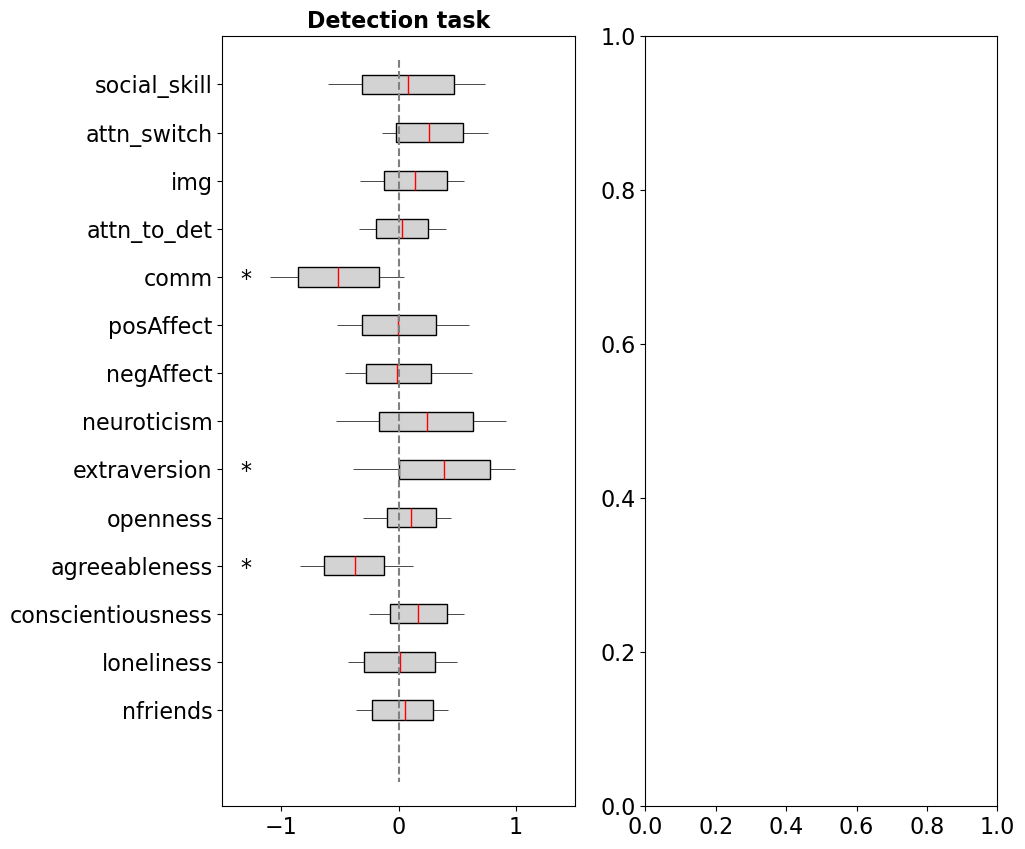

In [ ]:
# testing the pvalue we got above (in short, it's an approximation, iterative was more correct)
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,10))

ax = axs[0]
df_subt_quantiles = df_bootstrap_results_subt.quantile([0.029, 0.971])#([0.028, 0.972])#([0.0275, 0.9725])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_bootstrap_results_subt.mean()
df_subt_quantiles['min'] = df_bootstrap_results_subt.min()
df_subt_quantiles['max'] = df_bootstrap_results_subt.max()
# df = pd.DataFrame(df)
# df["lower_ci"] = df.quantile(0.025) #df["mean"] - 1.96*(df["std"]/np.sqrt(df["count"]))
# df["upper_ci"] = df["mean"] + 1.96*(df["std"]/np.sqrt(df["count"]))
for i, (_,row) in enumerate(df_subt_quantiles.iterrows()):
    y = i + 1
    width = row['upper_ci'] - row['lower_ci']
    rect = patches.Rectangle(
        (row['lower_ci'], i - 0.2),  # (x, y)
        width,
        0.4,  # height
        edgecolor='black',
        facecolor='lightgray'
    )
    ax.add_patch(rect)
    # ax.plot(row['mean'], i, 'o', color='red')
    ax.vlines(row['mean'], i - 0.2, i + 0.2, color='red', linewidth=1)

    # Whiskers
    ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
    ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

ax.vlines(0,-.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(0,14),df_bootstrap_results_subt.columns, rotation=0)
ax.set_title('Detection task', fontweight='bold')
ax.set_ylim(-1,15)
ax.set_xlim(-1.5,1.5)

xtext = -1.3
ind = -1
for i,row in df_subt_quantiles.iterrows(): 
    ind += 1
    if np.sign(row['lower_ci']) == np.sign(row['upper_ci']): 
        ax.text(xtext,ind + 0.05, '*', verticalalignment='center', horizontalalignment='center')

ax.invert_yaxis()

df_subt_quantiles


# permutations

In [ ]:
def shuffle_param(df,param):
    df[param] = df[param].sample(frac=1).reset_index(drop=True).values
    return df

In [ ]:
nperm = 10000 # 1000


In [ ]:

r2_subt = np.full((nperm),np.nan)
r2_pf = np.full((nperm),np.nan)
estimates_subt = np.full((nperm,15),np.nan)
estimates_pf = np.full((nperm,15),np.nan)

for i in range(nperm):
    if i%100 == 0:
       print('i=',i)
    df_subt = mixed_batch_data_zscored.copy()
    df_pf = mixed_batch_data_zscored.copy()

    param = 'bias_PSE_subt_diff'
    df_shuffle = shuffle_param(df_subt, param)
    model1 = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_shuffle)
    model1.fit(summary=False)
    if i == 0:
        colnames = model1.coefs.index
    estimates_subt[i,:] = model1.coefs['T-stat'].values #model.coefs.Estimate.values
    r2_subt[i] = model1.rsquared

    param = 'bias_PSE_pf_diff'
    df_shuffle = shuffle_param(df_pf, param)
    model2 = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_shuffle)
    model2.fit(summary=False)
    if i == 0:
        colnames = model2.coefs.index
    estimates_pf[i,:] = model2.coefs['T-stat'].values #model.coefs.Estimate.values
    r2_pf[i] = model2.rsquared

i= 0
i= 100
i= 200
i= 300
i= 400
i= 500
i= 600
i= 700
i= 800
i= 900
i= 1000
i= 1100
i= 1200
i= 1300
i= 1400
i= 1500
i= 1600
i= 1700
i= 1800
i= 1900
i= 2000
i= 2100
i= 2200
i= 2300
i= 2400
i= 2500
i= 2600
i= 2700
i= 2800
i= 2900
i= 3000
i= 3100
i= 3200
i= 3300
i= 3400
i= 3500
i= 3600
i= 3700
i= 3800
i= 3900
i= 4000
i= 4100
i= 4200
i= 4300
i= 4400
i= 4500
i= 4600
i= 4700
i= 4800
i= 4900
i= 5000
i= 5100
i= 5200
i= 5300
i= 5400
i= 5500
i= 5600
i= 5700
i= 5800
i= 5900
i= 6000
i= 6100
i= 6200
i= 6300
i= 6400
i= 6500
i= 6600
i= 6700
i= 6800
i= 6900
i= 7000
i= 7100
i= 7200
i= 7300
i= 7400
i= 7500
i= 7600
i= 7700
i= 7800
i= 7900
i= 8000
i= 8100
i= 8200
i= 8300
i= 8400
i= 8500
i= 8600
i= 8700
i= 8800
i= 8900
i= 9000
i= 9100
i= 9200
i= 9300
i= 9400
i= 9500
i= 9600
i= 9700
i= 9800
i= 9900


In [ ]:
df_shuffled_results_subt = pd.DataFrame(data=estimates_subt,columns=colnames)
df_shuffled_results_subt['r2'] = r2_subt
df_shuffled_results_pf = pd.DataFrame(data=estimates_pf,columns=colnames)
df_shuffled_results_pf['r2'] = r2_pf

df_shuffled_results_subt.to_csv('../../data/subtlety_playfight_data/traits/10k_perm_subtlety.csv')
df_shuffled_results_pf.to_csv('../../data/subtlety_playfight_data/traits/10k_perm_pf.csv')

In [ ]:
df_shuffled_results_subt=pd.read_csv('../../data/subtlety_playfight_data/traits/10k_perm_subtlety.csv', index_col=0)
df_shuffled_results_pf=pd.read_csv('../../data/subtlety_playfight_data/traits/10k_perm_pf.csv', index_col=0)

In [ ]:
df_subt = mixed_batch_data_zscored.copy()
df_pf = mixed_batch_data_zscored.copy()

param = 'bias_PSE_subt_diff'
model1_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_subt)
model1_og.fit(summary=False)
true_estimate_subtlety = model1_og.coefs['T-stat'].values
true_r2_subtlety = model1_og.rsquared

param = 'bias_PSE_pf_diff'
model2_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_pf)
model2_og.fit(summary=False)
true_estimate_pf = model2_og.coefs['T-stat'].values
true_r2_pf = model2_og.rsquared

In [ ]:
p_r2_subt = np.sum(df_shuffled_results_subt['r2'] >= true_r2_subtlety) / nperm
p_r2_pf = np.sum(df_shuffled_results_pf['r2'] >= true_r2_pf) / nperm
p_r2_subt, p_r2_pf

(np.float64(0.0337), np.float64(0.5004))

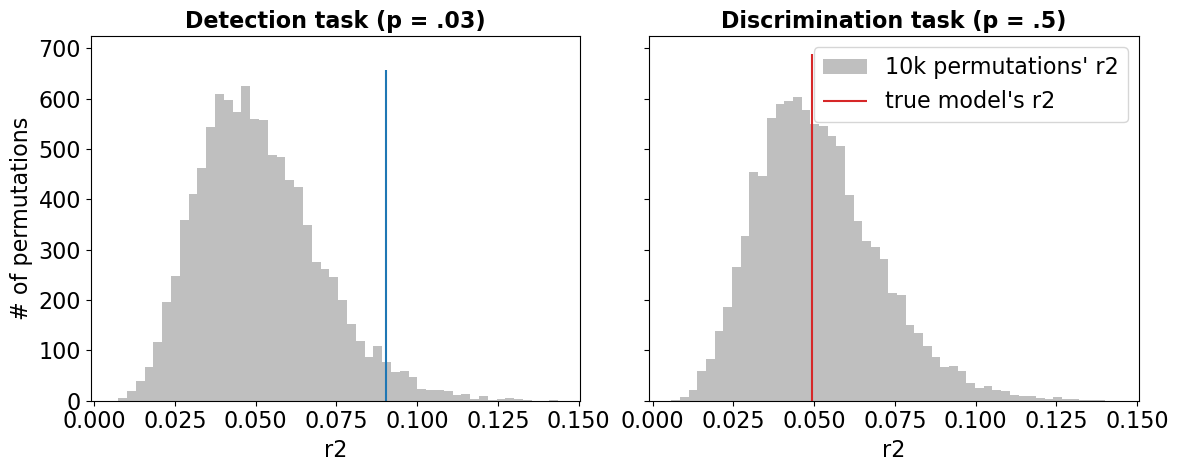

In [ ]:
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,5), sharex=True, sharey=True)
ax = axs[0]
ax.hist(df_shuffled_results_subt['r2'], bins=50, alpha=0.5, color='grey')
ax.vlines(true_r2_subtlety, 0, ax.get_ylim()[1], color='tab:blue')
# ax.set_title('Detection task', fontweight='bold')
ax.set_xlabel('r2')
ax.set_ylabel('# of permutations')
ax.set_title('Detection task (p = .03)', fontweight='bold')

ax = axs[1]
ax.hist(df_shuffled_results_pf['r2'], bins=50, alpha=0.5, color='grey', label="10k permutations' r2")
ax.vlines(true_r2_pf, 0, ax.get_ylim()[1], color='tab:red', label="true model's r2")
# ax.set_title('Discrimination task', fontweight='bold')
ax.set_xlabel('r2')
ax.set_ylabel('')
ax.set_title('Discrimination task (p = .5)', fontweight='bold')

plt.legend()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_r_sq_bias-PSE.png', dpi=300, bbox_inches = 'tight')

In [ ]:
def return_ptxt(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

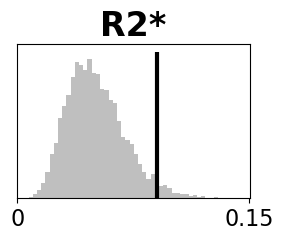

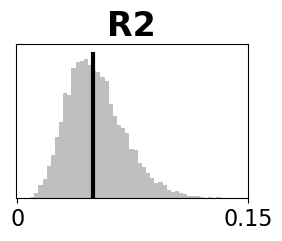

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(3,2), sharex=True, sharey=True)
ax.hist(df_shuffled_results_subt['r2'], bins=50, alpha=0.5, color='grey')
# ax.vlines(true_r2_subtlety, 0, ax.get_ylim()[1], color='tab:blue', linewidth=3)
ax.vlines(true_r2_subtlety, 0, ax.get_ylim()[1], color='k', label="true model's r2",linewidth=3)
# ax.set_title('Detection task', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('R2', fontweight='bold')
ax.set_xticks([0,.15])
ax.set_xticklabels(['0','0.15'])
# ax.set_yticks([0,600])#
ptxt = return_ptxt(p_r2_subt)
if p_r2_subt < .05:
    ax.set_title(f'R2{ptxt}', fontweight='bold', fontsize=24)
else:
    ax.set_title('R2', fontweight='bold', fontsize=24)
ax.set_yticks([])
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_r_sq_bias-PSE_det.png', transparent = True, dpi=300, bbox_inches = 'tight')

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(3,2), sharex=True, sharey=True)
ax.hist(df_shuffled_results_pf['r2'], bins=50, alpha=0.5, color='grey', label="10k permutations' r2")
# ax.vlines(true_r2_pf, 0, ax.get_ylim()[1], color='tab:red', label="true model's r2")
ax.vlines(true_r2_pf, 0, ax.get_ylim()[1], color='k', label="true model's r2",linewidth=3)
# ax.set_title('Discrimination task', fontweight='bold')
ax.set_xlabel('')
ax.set_xticks([0,.15])
ax.set_xticklabels(['0','0.15'])
ptxt = return_ptxt(p_r2_subt)
if p_r2_pf < .05:
    ax.set_title(f'R2{ptxt}', fontweight='bold', fontsize=24)
else:
    ax.set_title('R2', fontweight='bold', fontsize=24)
# ax.set_yticks([0,600])
ax.set_yticks([])
ax.set_ylabel('')
# ax.set_title('R2', fontweight='bold')
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_r_sq_bias-PSE_disc.png', transparent = True, dpi=300, bbox_inches = 'tight')


# range

In [ ]:
nperm = 10000 # 1000
r2_subt = np.full((nperm),np.nan)
r2_pf = np.full((nperm),np.nan)
estimates_subt = np.full((nperm,15),np.nan)
estimates_pf = np.full((nperm,15),np.nan)

for i in range(nperm):
    if i%100 == 0:
       print('i=',i)
    df_subt = mixed_batch_data_zscored.copy()
    df_pf = mixed_batch_data_zscored.copy()

    param = 'range_subt'
    df_shuffle = shuffle_param(df_subt, param)
    model1 = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_shuffle)
    model1.fit(summary=False)
    if i == 0:
        colnames = model1.coefs.index
    estimates_subt[i,:] = model1.coefs['T-stat'].values #model.coefs.Estimate.values
    r2_subt[i] = model1.rsquared

    param = 'range_pf'
    df_shuffle = shuffle_param(df_pf, param)
    model2 = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_shuffle)
    model2.fit(summary=False)
    if i == 0:
        colnames = model2.coefs.index
    estimates_pf[i,:] = model2.coefs['T-stat'].values #model.coefs.Estimate.values
    r2_pf[i] = model2.rsquared

i= 0
i= 100
i= 200
i= 300
i= 400
i= 500
i= 600
i= 700
i= 800
i= 900
i= 1000
i= 1100
i= 1200
i= 1300
i= 1400
i= 1500
i= 1600
i= 1700
i= 1800
i= 1900
i= 2000
i= 2100
i= 2200
i= 2300
i= 2400
i= 2500
i= 2600
i= 2700
i= 2800
i= 2900
i= 3000
i= 3100
i= 3200
i= 3300
i= 3400
i= 3500
i= 3600
i= 3700
i= 3800
i= 3900
i= 4000
i= 4100
i= 4200
i= 4300
i= 4400
i= 4500
i= 4600
i= 4700
i= 4800
i= 4900
i= 5000
i= 5100
i= 5200
i= 5300
i= 5400
i= 5500
i= 5600
i= 5700
i= 5800
i= 5900
i= 6000
i= 6100
i= 6200
i= 6300
i= 6400
i= 6500
i= 6600
i= 6700
i= 6800
i= 6900
i= 7000
i= 7100
i= 7200
i= 7300
i= 7400
i= 7500
i= 7600
i= 7700
i= 7800
i= 7900
i= 8000
i= 8100
i= 8200
i= 8300
i= 8400
i= 8500
i= 8600
i= 8700
i= 8800
i= 8900
i= 9000
i= 9100
i= 9200
i= 9300
i= 9400
i= 9500
i= 9600
i= 9700
i= 9800
i= 9900


In [ ]:
df_shuffled_results_subt_range = pd.DataFrame(data=estimates_subt,columns=colnames)
df_shuffled_results_subt_range['r2'] = r2_subt
df_shuffled_results_pf_range = pd.DataFrame(data=estimates_pf,columns=colnames)
df_shuffled_results_pf_range['r2'] = r2_pf

df_shuffled_results_subt_range.to_csv('../../data/subtlety_playfight_data/traits/10k_perm_subtlety_range.csv')
df_shuffled_results_pf_range.to_csv('../../data/subtlety_playfight_data/traits/10k_perm_pf_range.csv')

In [ ]:
df_shuffled_results_subt_range=pd.read_csv('../../data/subtlety_playfight_data/traits/10k_perm_subtlety_range.csv', index_col=0)
df_shuffled_results_pf_range=pd.read_csv('../../data/subtlety_playfight_data/traits/10k_perm_pf_range.csv', index_col=0)

In [ ]:
df_subt = mixed_batch_data_zscored.copy()
df_pf = mixed_batch_data_zscored.copy()

param = 'range_subt'
model1_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_subt)
model1_og.fit(summary=False)
true_estimate_subtlety = model1_og.coefs['T-stat'].values
true_r2_subtlety_range = model1_og.rsquared

param = 'range_pf'
model2_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_pf)
model2_og.fit(summary=False)
true_estimate_pf = model2_og.coefs['T-stat'].values
true_r2_pf_range = model2_og.rsquared

In [ ]:
p_r2_subt = np.sum(df_shuffled_results_subt_range['r2'] >= true_r2_subtlety_range) / nperm
p_r2_pf = np.sum(df_shuffled_results_pf_range['r2'] >= true_r2_pf_range) / nperm
p_r2_subt, p_r2_pf

(np.float64(0.5501), np.float64(0.004))

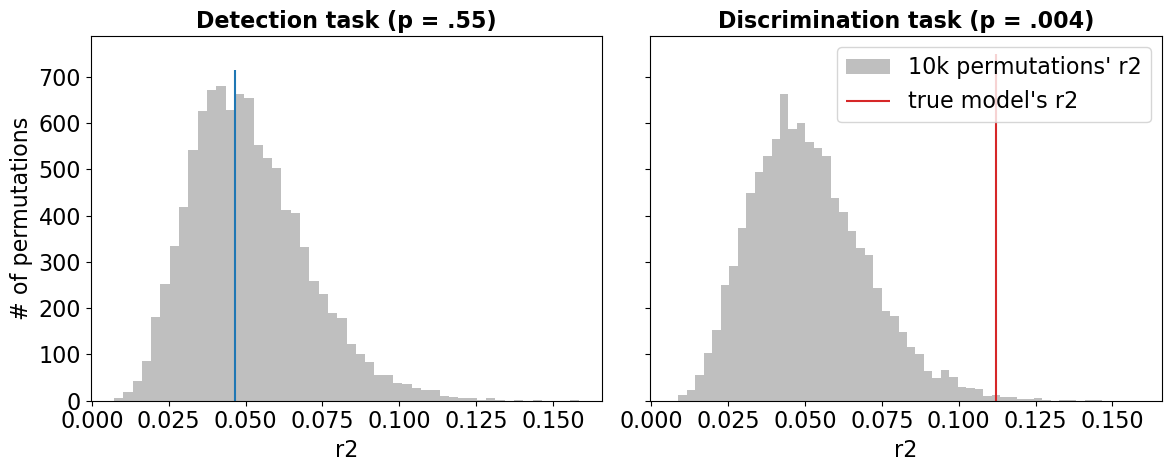

In [ ]:
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(12,5), sharex=True, sharey=True)
ax = axs[0]
ax.hist(df_shuffled_results_subt_range['r2'], bins=50, alpha=0.5, color='grey')
ax.vlines(true_r2_subtlety_range, 0, ax.get_ylim()[1], color='tab:blue')
# ax.set_title('Detection task', fontweight='bold')
ax.set_xlabel('r2')
ax.set_ylabel('# of permutations')
ax.set_title('Detection task (p = .55)', fontweight='bold')

ax = axs[1]
ax.hist(df_shuffled_results_pf_range['r2'], bins=50, alpha=0.5, color='grey', label="10k permutations' r2")
ax.vlines(true_r2_pf_range, 0, ax.get_ylim()[1], color='tab:red', label="true model's r2")
# ax.set_title('Discrimination task', fontweight='bold')
ax.set_xlabel('r2')
ax.set_ylabel('')
ax.set_title('Discrimination task (p = .004)', fontweight='bold')

# plt.suptitle('range', fontweight='bold')

plt.legend()

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_range.png', dpi=300, bbox_inches = 'tight')

In [ ]:
p_r2_subt, p_r2_pf

In [ ]:
ptxt

'**'

In [ ]:
p_r2_pf

np.float64(0.004)

In [ ]:
ptxt

'**'

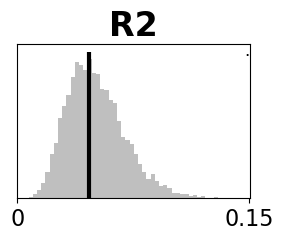

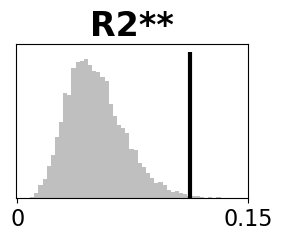

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(3,2), sharex=True, sharey=True)
ax.hist(df_shuffled_results_subt['r2'], bins=50, alpha=0.5, color='grey')
ax.vlines(true_r2_subtlety_range, 0, ax.get_ylim()[1], color='k', label="true model's r2", linewidth=3)
# ax.vlines(true_r2_subtlety_range, 0, ax.get_ylim()[1], color='tab:blue', linewidth=3)
# ax.set_title('Detection task', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([0,.15])
ax.set_xticklabels(['0','0.15'])
ptxt = return_ptxt(p_r2_subt)
if p_r2_subt < .05:
    ax.set_title(f'R2{ptxt}', fontweight='bold', fontsize=24)
else:
    ax.set_title('R2', fontweight='bold', fontsize=24)
ax.annotate(ptxt, xy=(1, 1), xycoords='axes fraction', fontsize=12, color='k', ha='right', va='top')
# ax.set_yticks([0,600])
ax.set_yticks([])
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_range_det.png', dpi=300, transparent= True, bbox_inches = 'tight')

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(3,2), sharex=True, sharey=True)
ax.hist(df_shuffled_results_pf['r2'], bins=50, alpha=0.5, color='grey', label="10k permutations' r2")
# ax.vlines(true_r2_pf_range, 0, ax.get_ylim()[1], color='tab:red', label="true model's r2")
ax.vlines(true_r2_pf_range, 0, ax.get_ylim()[1], color='k', label="true model's r2", linewidth=3)
# ax.set_title('Discrimination task', fontweight='bold')
ax.set_xlabel('')
ax.set_xticks([0,.15])
ax.set_xticklabels(['0','0.15'])
ptxt = return_ptxt(p_r2_pf)
if p_r2_pf < .05:
    ax.set_title(f'R2{ptxt}', fontweight='bold', fontsize=24)
else:
    ax.set_title('R2', fontweight='bold', fontsize=24)
# ax.annotate(ptxt, xy=(1, 1), xycoords='axes fraction', fontsize=40, color='k', ha='right', va='top')
# ax.set_yticks([0,600])
ax.set_yticks([])
ax.set_ylabel('')
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_perm_range_disc.png', dpi=300, transparent= True, bbox_inches = 'tight')


In [ ]:
p_all_subt = []
for i in range(14):
    # p = len(np.where(df_shuffled_results.iloc[:,1+i] > np.abs(true_estimate_subtlety[i]))[0])/ df_shuffled_results.shape[0]
    rule = ((df_shuffled_results_subt.iloc[:,1+i] > true_estimate_subtlety[i+1]) & (true_estimate_subtlety[i+1]>0)) | \
           ((df_shuffled_results_subt.iloc[:,1+i] < true_estimate_subtlety[i+1]) & (true_estimate_subtlety[i+1]<0)) 
    p = len(np.where(rule)[0])/ df_shuffled_results_subt.shape[0]
    p_all_subt.append(p)

p_all_pf = []
for i in range(14):
    # p = len(np.where(df_shuffled_results.iloc[:,1+i] > true_estimate_pf[i])[0])/ df_shuffled_results.shape[0]
    rule = ((df_shuffled_results_pf.iloc[:,1+i] > true_estimate_pf[i+1])&(true_estimate_pf[i+1]>0)) | \
           ((df_shuffled_results_pf.iloc[:,1+i] < true_estimate_pf[i+1])&(true_estimate_pf[i+1]<0)) 
    p = len(np.where(rule)[0])/ df_shuffled_results_pf.shape[0]
    
    p_all_pf.append(p)

In [ ]:
df_pval = pd.DataFrame(columns=df_bootstrap_results_subt.columns, data = np.array([p_all_subt,p_all_pf])).T
df_pval.columns = ['subt_pval', 'pf_pval']
df_pval

,subt_pval,pf_pval
social_skill,0.3374,0.4675
attn_switch,0.0488,0.4483
img,0.1459,0.4393
attn_to_det,0.3800,0.1520
comm,0.0028,0.2945
posAffect,0.5004,0.3107
negAffect,0.4749,0.1906
neuroticism,0.1126,0.4547
extraversion,0.0264,0.1493
openness,0.1579,0.0955


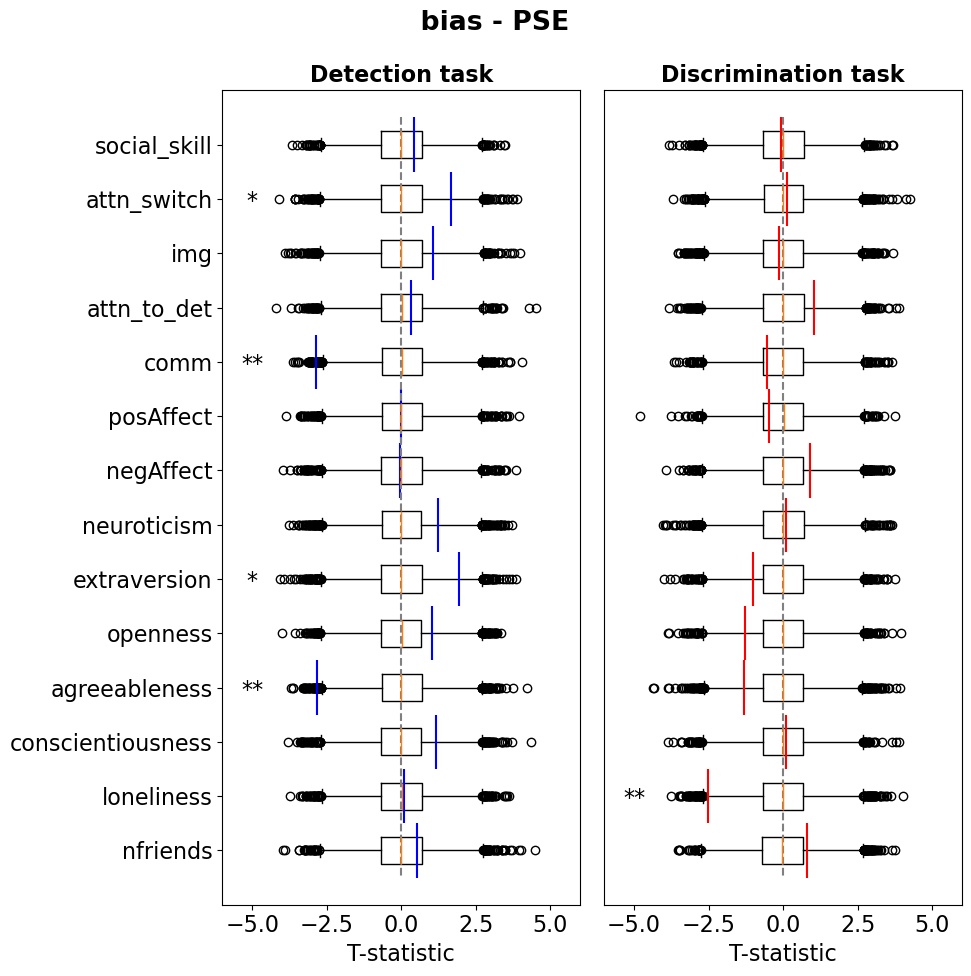

In [ ]:
# v1
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,10))

ax = axs[0]
ax.boxplot(df_shuffled_results_subt.iloc[:,1:], vert=False)#,  patch_artist=True, boxprops=dict(facecolor='w', color='k'))
# ax.boxplot(df_bootstrap_results_subt.values, vert=False, notch=True, bootstrap=10000)
# ax.boxplot(df_bootstrap_results_subt.iloc[:,1:], vert=False, bootstrap=10000,  patch_artist=True, boxprops=dict(facecolor='tab:blue', color='tab:blue'))
ax.vlines(true_estimate_subtlety[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'blue')
ax.vlines(0,0.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(1,15),df_shuffled_results_subt.columns[1:], rotation=0)
ax.set_title('Detection task', fontweight='bold')
# ax.set_xlim(-1.5,1.5)


xtext = -5

ax = axs[1]
ax.boxplot(df_shuffled_results_pf.iloc[:,1:], vert=False)#, patch_artist=True, boxprops=dict(facecolor='w', color='k'))
# ax.boxplot(df_bootstrap_results_pf.iloc[:,1:], vert=False, bootstrap=10000, patch_artist=True, boxprops=dict(facecolor='tab:red', color='tab:red'))
# ax.boxplot(df_bootstrap_results_subt.values, vert=False, notch=True, bootstrap=10000)
ax.vlines(true_estimate_pf[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'red')
ax.vlines(0,0.5,14.5,color = 'grey', ls = '--')
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')


ax = axs[0]
for i in range(14):  
    p = p_all_subt[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .05:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.set_xlabel('T-statistic')
ax.set_ylim(0,15)
ax.invert_yaxis()
ax.set_xlim(-6,6)

ax = axs[1]
for i in range(14):  
    p = p_all_pf[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .05:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.set_xlabel('T-statistic')#
ax.set_ylim(0,15)
ax.invert_yaxis()
ax.set_xlim(-6,6)

plt.suptitle('  bias - PSE', fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_permutations_v1.png', dpi=300, bbox_inches = 'tight')


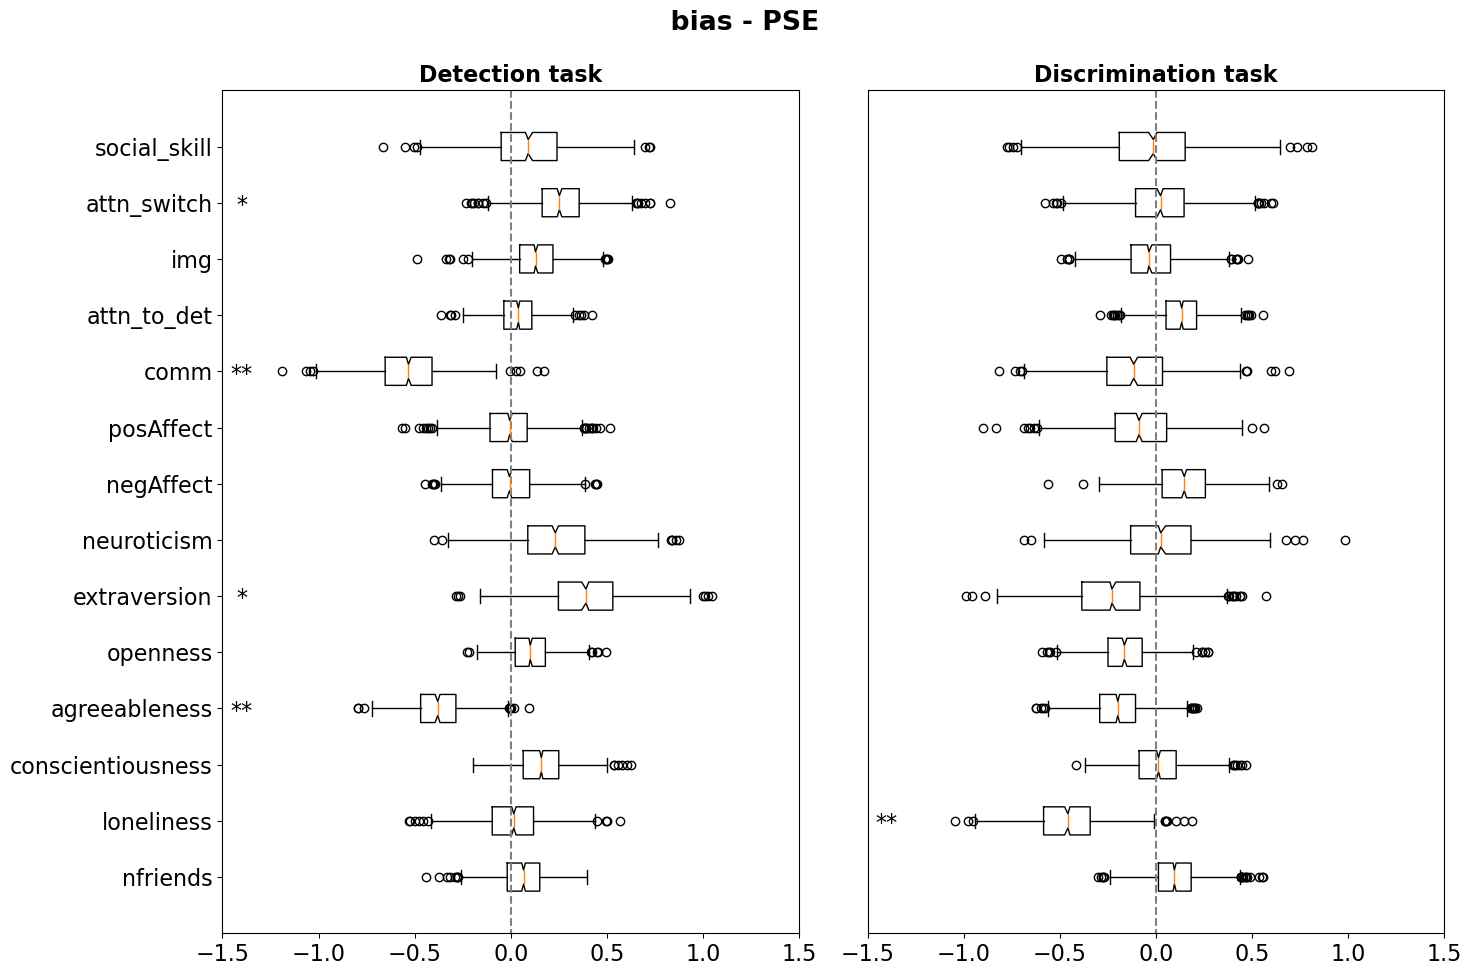

In [ ]:
# v2

fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(15,10))

ax = axs[0]
# ax.boxplot(df_shuffled_results_subt.iloc[:,1:], vert=False,  patch_artist=True, boxprops=dict(facecolor='w', color='k'))
ax.boxplot(df_bootstrap_results_subt.values, vert=False, notch=True, bootstrap=10000)
# ax.boxplot(df_bootstrap_results_subt.iloc[:,1:], vert=False, bootstrap=10000,  patch_artist=True, boxprops=dict(facecolor='tab:blue', color='tab:blue'))
# ax.vlines(true_estimate_subtlety[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'blue')
ax.vlines(0,0,15,color = 'grey', ls = '--')
ax.set_yticks(range(1,15),df_shuffled_results_subt.columns[1:], rotation=0)
ax.set_title('Detection task', fontweight='bold')
ax.set_xlim(-1.5,1.5)
ax.set_ylim(0,15)

ax = axs[1]
# ax.boxplot(df_shuffled_results_pf.iloc[:,1:], vert=False, patch_artist=True, boxprops=dict(facecolor='w', color='k'))
ax.boxplot(df_bootstrap_results_pf.values, vert=False, notch=True, bootstrap=10000)
# ax.boxplot(df_bootstrap_results_pf.iloc[:,1:], vert=False, bootstrap=10000, patch_artist=True, boxprops=dict(facecolor='tab:red', color='tab:red'))
# ax.vlines(true_estimate_pf[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'red')
ax.vlines(0,0,15,color = 'grey', ls = '--')
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')
ax.set_xlim(-1.5,1.5)
ax.set_ylim(0,15)

xtext = -1.4
ax = axs[0]
for i in range(14):  
    p = p_all_subt[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .05:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.invert_yaxis()

ax = axs[1]
for i in range(14):  
    p = p_all_pf[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .05:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.invert_yaxis()

plt.suptitle('  bias - PSE', fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_permutations_v2.png', dpi=300, bbox_inches = 'tight')


In [ ]:
len(true_estimate_subtlety)

15

In [ ]:
param = 'bias_PSE_subt_diff'
model1_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
model1_og.fit(summary=False)
true_estimate_subtlety = model1_og.coefs['T-stat'].values

param = 'bias_PSE_pf_diff'
model2_og = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
model2_og.fit(summary=False)
true_estimate_pf = model2_og.coefs['T-stat'].values

In [ ]:
xtext

-5

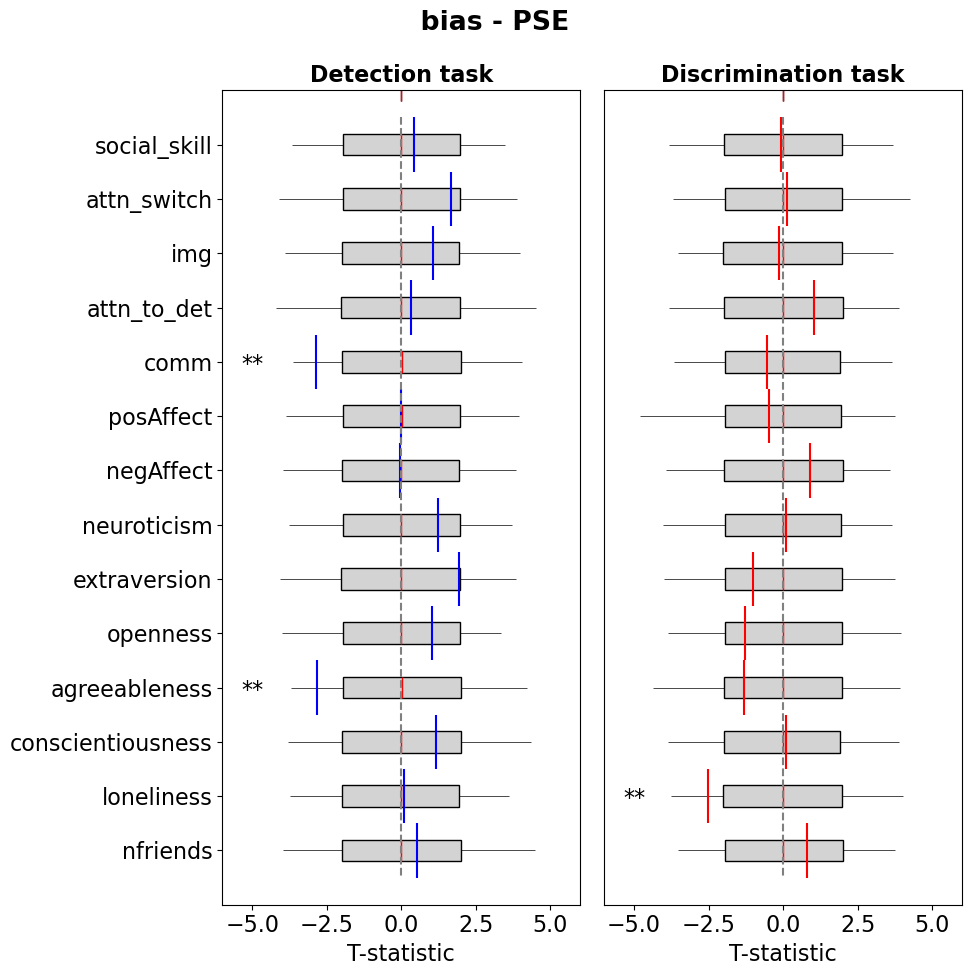

In [ ]:
# v3
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,10))

ax = axs[0]
df_subt_quantiles = df_shuffled_results_subt.quantile([0.025, 0.975])
df_subt_quantiles.index = ['lower_ci', 'upper_ci']
df_subt_quantiles = df_subt_quantiles.transpose()
df_subt_quantiles['mean'] = df_shuffled_results_subt.mean()
df_subt_quantiles['min'] = df_shuffled_results_subt.min()
df_subt_quantiles['max'] = df_shuffled_results_subt.max()

for i, (_,row) in enumerate(df_subt_quantiles.iterrows()):
    y = i + 1
    width = row['upper_ci'] - row['lower_ci']
    rect = patches.Rectangle(
        (row['lower_ci'], i - 0.2),  # (x, y)
        width,
        0.4,  # height
        edgecolor='black',
        facecolor='lightgray'
    )
    ax.add_patch(rect)
    ax.vlines(row['mean'], i - 0.2, i + 0.2, color='red', linewidth=1)

    # Whiskers
    ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
    ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

# ax.boxplot(df_shuffled_results_subt.iloc[:,1:], vert=False)#,  patch_artist=True, boxprops=dict(facecolor='w', color='k'))
ax.vlines(true_estimate_subtlety[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'blue')
ax.vlines(0,0.5,14.5,color = 'grey', ls = '--')
ax.set_yticks(range(1,15),df_shuffled_results_subt.columns[1:], rotation=0)
ax.set_title('Detection task', fontweight='bold')


xtext = -5

ax = axs[1]
df_pf_quantiles = df_shuffled_results_pf.quantile([0.025, 0.975])
df_pf_quantiles.index = ['lower_ci', 'upper_ci']
df_pf_quantiles = df_pf_quantiles.transpose()
df_pf_quantiles['mean'] = df_shuffled_results_pf.mean()
df_pf_quantiles['min'] = df_shuffled_results_pf.min()
df_pf_quantiles['max'] = df_shuffled_results_pf.max()

for i, (_,row) in enumerate(df_pf_quantiles.iterrows()):
    y = i + 1
    width = row['upper_ci'] - row['lower_ci']
    rect = patches.Rectangle(
        (row['lower_ci'], i - 0.2),  # (x, y)
        width,
        0.4,  # height
        edgecolor='black',
        facecolor='lightgray'
    )
    ax.add_patch(rect)
    ax.vlines(row['mean'], i - 0.2, i + 0.2, color='red', linewidth=1)

    # Whiskers
    ax.hlines(i, row['min'], row['lower_ci'], color='black', linewidth=.5)   # left whisker
    ax.hlines(i, row['upper_ci'], row['max'], color='black', linewidth=.5)  # right whisker

# ax.boxplot(df_shuffled_results_pf.iloc[:,1:], vert=False)#, patch_artist=True, boxprops=dict(facecolor='w', color='k'))
ax.vlines(true_estimate_pf[1:],np.arange(1,15)-.5,np.arange(1,15)+.5, color = 'red')
ax.vlines(0,0.5,14.5,color = 'grey', ls = '--')
ax.set_yticks([])
ax.set_title('Discrimination task', fontweight='bold')


ax = axs[0]
for i in range(14):  
    p = p_all_subt[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .025:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.set_xlabel('T-statistic')
ax.set_ylim(0,15)
ax.invert_yaxis()
ax.set_xlim(-6,6)

ax = axs[1]
for i in range(14):  
    p = p_all_pf[i]
    if p < .001:
        ax.text(xtext,i + 1.05, '***', verticalalignment='center', horizontalalignment='center')
    elif p < .01:
        ax.text(xtext,i + 1.05, '**', verticalalignment='center', horizontalalignment='center')
    elif p < .025:
        ax.text(xtext,i + 1.05, '*', verticalalignment='center', horizontalalignment='center')
ax.set_xlabel('T-statistic')#
ax.set_ylim(0,15)
ax.invert_yaxis()
ax.set_xlim(-6,6)

plt.suptitle('  bias - PSE', fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/subtlety_playfight_mixed/trait-beh/trat_beh_multreg_permutations_v3.png', dpi=300, bbox_inches = 'tight')


# looking at the ratio or log-ratio with raw data

In [ ]:
mixed_batch_data['PSE_subt'].describe()

In [ ]:
len(np.where(mixed_batch_data['PSE_subt']==0)[0]), mixed_batch_data.shape[0], 100*9/274

In [ ]:
len(np.where(mixed_batch_data['PSE_pf']==0)[0]), mixed_batch_data.shape[0], 100*2/274

In [ ]:
mixed_batch_data['PSE_subt'] = [0.01 if i==0 else i for i in mixed_batch_data['PSE_subt']]
mixed_batch_data['PSE_pf'] = [0.01 if i==0 else i for i in mixed_batch_data['PSE_pf']]

In [ ]:
bias_PSE_subt = mixed_batch_data['bias_subt']/ mixed_batch_data['PSE_subt']
log_bias_PSE_subt = np.log(mixed_batch_data['bias_subt']/ mixed_batch_data['PSE_subt'])
bias_PSE_subt_diff = mixed_batch_data['bias_subt'] - mixed_batch_data['PSE_subt']

bias_PSE_pf = mixed_batch_data['bias_pf']/ mixed_batch_data['PSE_pf']
log_bias_PSE_pf = np.log(mixed_batch_data['bias_pf']/ mixed_batch_data['PSE_pf'])
bias_PSE_pf_diff = mixed_batch_data['bias_subt'] - mixed_batch_data['PSE_subt']

mixed_batch_data.insert(3, 'bias_PSE_subt', bias_PSE_subt)
mixed_batch_data.insert(4, 'log_bias_PSE_subt', log_bias_PSE_subt)
mixed_batch_data.insert(5, 'bias_PSE_subt_diff', bias_PSE_subt_diff)

mixed_batch_data.insert(9, 'bias_PSE_pf', bias_PSE_pf)
mixed_batch_data.insert(10, 'log_bias_PSE_pf', log_bias_PSE_pf)
mixed_batch_data.insert(10, 'bias_PSE_pf_diff', bias_PSE_pf_diff)
mixed_batch_data

In [ ]:
plt.hist(mixed_batch_data['PSE_subt'])

In [ ]:
plt.hist(mixed_batch_data['log_bias_PSE_subt'])

In [ ]:
trait_cols

In [ ]:
param = 'bias_PSE_subt'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data)
print(model.fit())

In [ ]:
param = 'log_bias_PSE_subt' # higher value --> higher social bias
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data)
print(model.fit())

In [ ]:
estimates = np.full((100,15),np.nan)
for i in range(100):
    param = 'log_bias_PSE_subt' # higher value --> higher social bias
    inds = generate_samples(np.arange(0,mixed_batch_data.shape[0]), mixed_batch_data.shape[0])

    df_bootstrap = mixed_batch_data.iloc[inds,:]

    model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
    model.fit(summary=False)
    # print(model.fit())
    if i == 0:
        colnames = model.coefs.index
    estimates[i,:] = model.coefs.Estimate.values

plt.figure(figsize=(5,10))
df_bootstrap_results = pd.DataFrame(data=estimates,columns=colnames)
plt.boxplot(df_bootstrap_results.iloc[:,1:], vert=False)
plt.vlines(0,0,15,color = 'grey', ls = '--')
plt.yticks(range(1,15),df_bootstrap_results.columns[1:], rotation=0)
plt.title('log bias/PSE', fontweight='bold')

p_all = []
for i in range(14):
    _,p = stats.ttest_1samp(df_bootstrap_results.iloc[:,i+1],0)    
    p_all.append(p)
p_all_corr = fdrcorrection(p_all)
for i in range(14):

    # p = p_all[i]
    # if p < .001:
    #     plt.gca().text(.1,i + 1, '***', verticalalignment='center')
    # elif p < .01:
    #     plt.gca().text(.1,i + 1, '**')
    # elif p < .05:
    #     plt.gca().text(.1,i + 1, '*')
        
    if p_all_corr[0][i]:
        p = p_all[i]
        if p < .001:
            plt.gca().text(-.1,i + 1, '***', verticalalignment='center')
        elif p < .01:
            plt.gca().text(-.1,i + 1, '**')
        elif p < .05:
            plt.gca().text(-.1,i + 1, '*')

        # p = p_all_corr[1][i]
        # if p < .001:
        #     plt.gca().text(.1,i + 1, '***', verticalalignment='center')
        # elif p < .01:
        #     plt.gca().text(.1,i + 1, '**')
        # elif p < .05:
        #     plt.gca().text(.1,i + 1, '*')
plt.xlim(-.12,.1)
p_all_corr

In [ ]:
param = 'bias_PSE_pf' # higher value --> higher tendency to detect fight
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data)
print(model.fit())

In [ ]:
param = 'log_bias_PSE_pf'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data)
print(model.fit())

In [ ]:
estimates = np.full((100,15),np.nan)
for i in range(100):
    param = 'log_bias_PSE_pf' # higher value --> higher social bias
    inds = generate_samples(np.arange(0,mixed_batch_data.shape[0]), mixed_batch_data.shape[0])

    df_bootstrap = mixed_batch_data.iloc[inds,:]

    model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=df_bootstrap)
    model.fit(summary=False)
    # print(model.fit())
    if i == 0:
        colnames = model.coefs.index
    estimates[i,:] = model.coefs.Estimate.values

plt.figure(figsize=(5,10))
df_bootstrap_results = pd.DataFrame(data=estimates,columns=colnames)
plt.boxplot(df_bootstrap_results.iloc[:,1:], vert=False)
plt.vlines(0,0,15,color = 'grey', ls = '--')
plt.yticks(range(1,15),df_bootstrap_results.columns[1:], rotation=0)
plt.title('log bias/PSE', fontweight='bold')

p_all = []
for i in range(14):
    _,p = stats.ttest_1samp(df_bootstrap_results.iloc[:,i+1],0)    
    p_all.append(p)
p_all_corr = fdrcorrection(p_all)

for i in range(14):

    # p = p_all[i]
    # if p < .001:
    #     plt.gca().text(.1,i + 1, '***', verticalalignment='center')
    # elif p < .01:
    #     plt.gca().text(.1,i + 1, '**')
    # elif p < .05:
    #     plt.gca().text(.1,i + 1, '*')
        
    if p_all_corr[0][i]:
        p = p_all[i]
        if p < .001:
            plt.gca().text(-.25,i + 1, '***', verticalalignment='center')
        elif p < .01:
            plt.gca().text(-.25,i + 1, '**')
        elif p < .05:
            plt.gca().text(-.25,i + 1, '*')

        # p = p_all_corr[1][i]
        # if p < .001:
        #     plt.gca().text(.1,i + 1, '***', verticalalignment='center')
        # elif p < .01:
        #     plt.gca().text(.1,i + 1, '**')
        # elif p < .05:
        #     plt.gca().text(.1,i + 1, '*')
plt.xlim(-.3,.3)
p_all_corr

In [ ]:
param = 'bias_PSE_pf_diff'
model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data)
print(model.fit())

In [ ]:
param_list = ['bias_PSE_subt','bias_PSE_subt_diff','bias_subt','PSE_subt']

all_ps = np.full((len(trait_cols),len(param_list)),np.nan) # for MCC
for iparam,param in enumerate(param_list):
    print(f'\nPARAM {param}')
    model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
    print(model.fit())
    for t,trait in enumerate(trait_cols): # for MCC
        all_ps[t, iparam] = model.coefs['P-val'][trait]

In [ ]:
param_list = ['bias_PSE_pf','bias_PSE_pf_diff', 'bias_pf','PSE_pf']

all_ps = np.full((len(trait_cols),len(param_list)),np.nan) # for MCC
for iparam,param in enumerate(param_list):
    print(f'\nPARAM {param}')
    model = Lm(f"{param} ~ social_skill + attn_switch + img + attn_to_det + comm + posAffect + negAffect + neuroticism + extraversion + openness + agreeableness + conscientiousness + loneliness + nfriends", data=mixed_batch_data_zscored)
    print(model.fit())
    for t,trait in enumerate(trait_cols): # for MCC
        all_ps[t, iparam] = model.coefs['P-val'][trait]

In [ ]:
result_bool = np.full_like(all_ps,np.nan)
corrected_p = np.full_like(all_ps,np.nan)
for t, trait in enumerate(trait_cols): # MCC one PC at a time
    result_bool[t,:], corrected_p[t,:] = fdrcorrection(all_ps[t,:]) # MCC across all params for one PC (regressor) at a time
    print(trait, np.where(result_bool[t,:])[0], np.array(param_list)[np.where(result_bool[t,:])[0]])

In [ ]:
from scipy import stats

In [ ]:
x = mixed_batch_data_zscored['comm']
y = mixed_batch_data_zscored['bias_subt']
stats.pearsonr(x,y)

In [ ]:
x = mixed_batch_data_zscored['agreeableness']
y = mixed_batch_data_zscored['PSE_subt']
stats.pearsonr(x,y)